# Phase 4 — Scenario Simulation (Steps 17–21)
## Kandy District LUTI Model — *Dynamic Land-Use / Transport Interaction*

**Research:** An Integrated LUTI Model for Sustainable Urban Growth in Kandy
**Author:** K. Abishek (20GES1432), Department of Remote Sensing & GIS, Sabaragamuwa University of Sri Lanka
**Supervisor:** Prof. RMKGSPB Koswatte
**Date:** April 2026

---

## Phase Overview

Phase 4 is the **experimental core** of the LUTI methodology. With the model calibrated
in Phase 2 (Steps 9–12), four scenarios are each run through the same 20-year dynamic
feedback loop and their outputs compared against four evaluation metrics.

| Step | Description | Tool |
|------|-------------|------|
| **17** | Baseline (Do-Nothing) — no new transport investment | AequilibraE + UrbanSim-style MNL |
| **18** | Scenario A — Kohuwala–Gatambe Highway Bypass | AequilibraE network modification |
| **19** | Scenario B — Bus Rapid Transit (BRT) System | GTFS feed + OTP transit skims |
| **20** | Scenario C — Transit-Oriented Development (BRT + upzoning) | GTFS + TOD zoning override |
| **21** | Compile results, statistics, visualisations, save outputs | pandas / matplotlib |

## Prerequisites
- ✅ **Step 9** — AequilibraE project built; congested & free-flow skims saved
- ✅ **Step 10** — Model calibrated (GEH ≥ 85 %); calibrated beta saved
- ✅ **Step 11** — UrbanSim tables assembled (zones, buildings, households, jobs)
- ✅ **Step 12** — LUTI feedback loop proven; baseline scenario outputs available
- ⏭️  **Steps 13–16** (Phase 3 — Historical Validation) — *skipped due to time constraints*

## Four Evaluation Metrics
| Metric | Indicator | Formula |
|--------|-----------|---------|
| Urban Sprawl | Shannon Entropy Index | $H = -\sum p_i \ln(p_i) / \ln(n)$ |
| Housing Affordability | Income-to-Housing Ratio | Median HH Income / Median Housing Cost |
| Traffic Congestion | Volume-to-Capacity ratio | Link flow / Link capacity |
| Air Quality | Daily emissions (CO₂, NOₓ, PM₂.₅) | VKT × emission factors |

**Time horizon:** 2026 → 2031 → 2036 → 2041 → 2046 (four 5-year cycles)


In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Imports and environment check
# ══════════════════════════════════════════════════════════════
import os, json, warnings, copy, pickle
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

warnings.filterwarnings('ignore')
np.random.seed(42)   # Reproducible Monte Carlo draws

# ── Optional: AequilibraE ─────────────────────────────────────
try:
    from aequilibrae import Project, AequilibraeMatrix
    AEQ_AVAILABLE = True
    print('✓ AequilibraE available — live network assignment enabled')
except ImportError:
    AEQ_AVAILABLE = False
    print('ℹ  AequilibraE not installed — using pre-computed CSV skims')
    print('   Install with:  pip install aequilibrae')

# ── Optional: GeoPandas (for spatial maps) ─────────────────────
try:
    import geopandas as gpd
    from shapely.geometry import Point
    GPD_AVAILABLE = True
    print('✓ GeoPandas available — spatial visualisations enabled')
except ImportError:
    GPD_AVAILABLE = False
    print('ℹ  GeoPandas not installed — spatial maps use centroid scatter plots')
    print('   Install with:  pip install geopandas')

print(f'\nnumpy  {np.__version__}  |  pandas  {pd.__version__}')
print('Phase 4 environment ready.')


✓ AequilibraE available — live network assignment enabled
✓ GeoPandas available — spatial visualisations enabled

numpy  2.4.2  |  pandas  3.0.0
Phase 4 environment ready.


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Path configuration and directory creation
# ══════════════════════════════════════════════════════════════
BASE_DIR      = Path(r'E:\LUTI Research\kandy_luti')

# ── Step 9 / 10 inputs ───────────────────────────────────────
TRANSPORT_DIR = BASE_DIR / 'transport'
BASELINE_TRP  = TRANSPORT_DIR / 'baseline'
CALIB_DIR     = TRANSPORT_DIR / 'calibration'
PROJECT_PATH  = str(BASELINE_TRP / 'aeq_project')

SKIM_FF_CSV   = BASELINE_TRP / 'travel_time_skim_freeflow.csv'
SKIM_CG_CSV   = BASELINE_TRP / 'travel_time_skim_congested.csv'
OD_CSV        = BASELINE_TRP / 'od_matrix_gravity.csv'
FLOWS_CSV     = BASELINE_TRP / 'link_assignment_results.csv'
CALIB_CSV     = CALIB_DIR   / 'calibrated_parameters.csv'

# ── Census / socioeconomic ────────────────────────────────────
CENSUS_CSV    = BASE_DIR / 'data' / 'census' / 'Kandy_TAZ_SocioEconomic.csv'
ZONING_XLSX   = BASE_DIR / 'data' / 'census' / 'Kandy_LandUse_Zoning_Dataset.xlsx'
PROP_XLSX     = BASE_DIR / 'data' / 'census' / 'Kandy_Property_Values_Dataset.xlsx'

# ── Phase 4 outputs ───────────────────────────────────────────
RESULTS_DIR   = BASE_DIR / 'results'
LU_DIR        = BASE_DIR / 'land_use'
OTP_DIR       = BASE_DIR / 'otp'
GTFS_DIR      = OTP_DIR  / 'gtfs_kandy_brt'
PHASE4_DIR    = RESULTS_DIR / 'phase4'

SCENARIOS = ['baseline', 'scenario_a', 'scenario_b', 'scenario_c']
SCENARIO_LABELS = {
    'baseline':   'Baseline (Do-Nothing)',
    'scenario_a': 'Scenario A — Highway Bypass',
    'scenario_b': 'Scenario B — BRT System',
    'scenario_c': 'Scenario C — TOD (BRT + Upzoning)',
}
SCENARIO_COLORS = {
    'baseline':   '#555555',
    'scenario_a': '#E74C3C',
    'scenario_b': '#2980B9',
    'scenario_c': '#27AE60',
}
TIME_STEPS = [2026, 2031, 2036, 2041, 2046]

# Create output directories
for s in SCENARIOS:
    (LU_DIR    / s).mkdir(parents=True, exist_ok=True)
    (RESULTS_DIR / s).mkdir(parents=True, exist_ok=True)
PHASE4_DIR.mkdir(parents=True, exist_ok=True)
GTFS_DIR.mkdir(parents=True, exist_ok=True)
(TRANSPORT_DIR / 'scenario_b').mkdir(parents=True, exist_ok=True)

# ── Verify critical prerequisite files ───────────────────────
print('Verifying Step 9/10/12 prerequisite files...')
required = {
    'Congested skim'    : SKIM_CG_CSV,
    'Free-flow skim'    : SKIM_FF_CSV,
    'OD matrix'         : OD_CSV,
    'Link flows'        : FLOWS_CSV,
    'Calibrated params' : CALIB_CSV,
    'Census / TAZ data' : CENSUS_CSV,
    'Zoning dataset'    : ZONING_XLSX,
}
all_ok = True
for name, path in required.items():
    ok = path.exists()
    print(f'  {"✓" if ok else "✗"} {name:<22} {path.name}')
    if not ok:
        all_ok = False

if not all_ok:
    raise FileNotFoundError(
        'One or more prerequisite files are missing. '
        'Ensure Steps 9, 10, and 12 have been run successfully.'
    )
print('\\n✓ All prerequisites verified. Proceeding with Phase 4.')


Verifying Step 9/10/12 prerequisite files...
  ✓ Congested skim         travel_time_skim_congested.csv
  ✓ Free-flow skim         travel_time_skim_freeflow.csv
  ✓ OD matrix              od_matrix_gravity.csv
  ✓ Link flows             link_assignment_results.csv
  ✓ Calibrated params      calibrated_parameters.csv
  ✓ Census / TAZ data      Kandy_TAZ_SocioEconomic.csv
  ✓ Zoning dataset         Kandy_LandUse_Zoning_Dataset.xlsx
\n✓ All prerequisites verified. Proceeding with Phase 4.


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Load calibrated model components from Steps 9 & 10
# ══════════════════════════════════════════════════════════════

# ── 3a. TAZ socioeconomic data ────────────────────────────────
print('Loading TAZ socioeconomic data...')
census = pd.read_csv(CENSUS_CSV)
census.columns = census.columns.str.strip()
census['TAZ_ID'] = census['TAZ_ID'].astype(int)
census = census.set_index('TAZ_ID').sort_index()
N_ZONES  = len(census)
zone_ids = census.index.tolist()
print(f'  Zones              : {N_ZONES:,}')
print(f'  Total population   : {census["Pop_2024"].sum():,.0f}')
print(f'  Total households   : {census["Num_Households"].sum():,.0f}')
print(f'  Total employment   : {census["Total_Employment"].sum():,.0f}')

# ── 3b. Calibrated parameters ─────────────────────────────────
print('\nLoading calibrated transport parameters...')
_raw = pd.read_csv(CALIB_CSV, header=None, names=['param', 'value'])
calib = dict(zip(_raw['param'], _raw['value']))
BETA_CALIBRATED = float(calib['optimal_beta'])
GEH_PASS_PCT    = float(calib['geh_pass_pct'])
MEAN_TT_MIN     = float(calib.get('beta_avg_tt_min', 20.4))
print(f'  Calibrated beta (β)  : {BETA_CALIBRATED}')
print(f'  GEH pass rate        : {GEH_PASS_PCT:.1f}%  (target ≥ 85%)')
print(f'  Mean network TT      : {MEAN_TT_MIN:.1f} min')
print(f'  Calibration status   : {calib.get("calibration_status", "PASS")}')

# ── 3c. Congested skim matrix ─────────────────────────────────
print('\nLoading congested travel-time skim...')
_skim_raw = pd.read_csv(SKIM_CG_CSV, index_col=0)
_skim_raw.index   = _skim_raw.index.astype(int)
_skim_raw.columns = _skim_raw.columns.astype(int)
SKIM_BASE = _skim_raw.reindex(index=zone_ids, columns=zone_ids).fillna(999).values
if SKIM_BASE[SKIM_BASE < 999].mean() > 300:   # seconds → minutes
    SKIM_BASE /= 60.0
np.fill_diagonal(SKIM_BASE, 0.0)
_reach = (SKIM_BASE < 999).mean()
print(f'  Shape              : {SKIM_BASE.shape}')
print(f'  Reachability       : {_reach:.1%}')
print(f'  Mean TT (reachable): {SKIM_BASE[SKIM_BASE < 999].mean():.1f} min')

# ── 3d. Free-flow skim ────────────────────────────────────────
_ff_raw = pd.read_csv(SKIM_FF_CSV, index_col=0)
_ff_raw.index   = _ff_raw.index.astype(int)
_ff_raw.columns = _ff_raw.columns.astype(int)
SKIM_FF = _ff_raw.reindex(index=zone_ids, columns=zone_ids).fillna(999).values
if SKIM_FF[SKIM_FF < 999].mean() > 300:
    SKIM_FF /= 60.0
np.fill_diagonal(SKIM_FF, 0.0)

# ── 3e. Link assignment results ───────────────────────────────
print('\nLoading link assignment results...')
FLOWS = pd.read_csv(FLOWS_CSV)
FLOWS.columns = FLOWS.columns.str.strip()
print(f'  Links with flows   : {len(FLOWS):,}')
print(f'  Total PCE volume   : {FLOWS["PCE_tot"].sum():,.0f} vehicles/day')

# ── 3f. Zone centroids (lat/lon) ──────────────────────────────
zone_lat_raw = census['centroid_y'].values
zone_lon_raw = census['centroid_x'].values
# Convert EPSG:5235 (Sri Lanka Grid 1999) → WGS84 approximate conversion
# EPSG:5235 parameters: lat origin = 7.0001°N, central meridian = 80.7715°E,
# false easting = false northing = 500,000 m, scale factor = 0.9999238
LAT_ORIGIN = 7.0001    # degrees N
LON_ORIGIN = 80.7715   # degrees E (central meridian)
FALSE_N    = 500_000.0 # false northing (metres)
FALSE_E    = 500_000.0 # false easting (metres)

if zone_lat_raw.mean() > 10000:   # values are in projected metres (not degrees)
    zone_lat = LAT_ORIGIN + (zone_lat_raw - FALSE_N) / 110_574.0
    zone_lon = LON_ORIGIN + (zone_lon_raw - FALSE_E) / (111_320.0 * np.cos(np.radians(LAT_ORIGIN)))
else:
    zone_lat = zone_lat_raw        # already in degrees
    zone_lon = zone_lon_raw

# Sanity check — Kandy District should be ~7.2°–7.45°N, ~80.4°–80.85°E
lat_ok = 6.5 <= zone_lat.mean() <= 8.0
lon_ok = 79.5 <= zone_lon.mean() <= 82.0
print(f'  Zone centroid mean: lat={zone_lat.mean():.3f}°N  lon={zone_lon.mean():.3f}°E'
      f'  [{"✓" if lat_ok and lon_ok else "WARN — check EPSG conversion"}]')

# ── 3g. Zoning datasets ───────────────────────────────────────
print('\nLoading land-use zoning data...')
ZONING_CATS = pd.read_excel(ZONING_XLSX, sheet_name='Zoning_Categories')
PARCEL_DATA = pd.read_excel(ZONING_XLSX, sheet_name='LandUse_Parcel_Data')
TOD_MODS    = pd.read_excel(ZONING_XLSX, sheet_name='TOD_Zone_Modifications')
TOD_MODS    = TOD_MODS.dropna(subset=['Station_ID']).copy()
# Fix numeric columns that may have been read as strings
for col in ['Lat','Lon','Proposed Max FAR','Current Max FAR','Catchment Radius (m)']:
    if col in TOD_MODS.columns:
        TOD_MODS[col] = pd.to_numeric(TOD_MODS[col], errors='coerce')
TOD_MODS = TOD_MODS.dropna(subset=['Lat','Lon'])
print(f'  TOD station mods   : {len(TOD_MODS)}')

# ── 3h. Metrics comparison dict ───────────────────────────────
metrics_to_compare = {
    'Population'         : ('population',          ',.0f'),
    'Employment'         : ('employment',           ',.0f'),
    'Housing units'      : ('housing_units',        ',.0f'),
    'Mean accessibility' : ('mean_accessibility',   '.4f'),
    'Shannon entropy'    : ('shannon_entropy',      '.4f'),
    'Affordability ratio': ('affordability_ratio',  '.3f'),
    'Trip demand'        : ('total_trip_demand',    ',.0f'),
}

print('\n✓ All calibrated components loaded.')


Loading TAZ socioeconomic data...
  Zones              : 1,202
  Total population   : 1,377,838
  Total households   : 367,085
  Total employment   : 399,278

Loading calibrated transport parameters...
  Calibrated beta (β)  : 0.11
  GEH pass rate        : 87.5%  (target ≥ 85%)
  Mean network TT      : 20.4 min
  Calibration status   : PASS

Loading congested travel-time skim...
  Shape              : (1202, 1202)
  Reachability       : 100.0%
  Mean TT (reachable): 59.5 min

Loading link assignment results...
  Links with flows   : 17,754
  Total PCE volume   : 30,779,930 vehicles/day
  Zone centroid mean: lat=7.284°N  lon=80.643°E  [✓]

Loading land-use zoning data...
  TOD station mods   : 7

✓ All calibrated components loaded.


---
## Core LUTI Simulation Engine

The cell below defines `run_luti_simulation()` — the standalone function called by all
four scenario steps (17–20). It replicates the calibrated feedback loop from Step 12
but accepts scenario-specific parameters as arguments, making every scenario run
fully independent and reproducible.

**Algorithm (per 5-year cycle):**
1. Compute Hansen accessibility $A_i = \sum_j E_j \cdot e^{-\beta t_{ij}}$
2. Grow population (+1.0%/yr) and employment (+1.2%/yr) using calibrated rates
3. Redistribute marginal growth across zones weighted by accessibility (HLCM/ELCM proxy)
4. Developer Model: build new housing units where demand > supply and FAR allows
5. Update hedonic land prices using accessibility and BRT premium
6. Compute aggregate metrics (Shannon entropy, affordability, V/C proxy)
7. Save zone CSV and append to metrics timeseries


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — LUTI Simulation Engine
# ══════════════════════════════════════════════════════════════

def compute_accessibility(skim, employment_series, beta):
    """Hansen cumulative-opportunity accessibility.
    A_i = sum_j E_j * exp(-beta * t_ij)
    """
    skim_c = np.minimum(skim, 120.0)   # Cap at 120 min
    decay  = np.exp(-beta * skim_c)
    np.fill_diagonal(decay, 0.0)
    return decay @ employment_series.values.astype(float)


def shannon_entropy(population_series):
    """Normalised Shannon Entropy H in [0,1]. Higher = more dispersed (sprawl)."""
    pop = population_series.values.astype(float)
    pop = pop[pop > 0]
    total = pop.sum()
    if total == 0 or len(pop) < 2:
        return np.nan
    p = pop / total
    return -np.sum(p * np.log(p)) / np.log(len(pop))


def run_luti_simulation(
    scenario_name,
    skim_modifier=None,
    zoning_far_override=None,
    brt_zone_ids=None,
    force_rerun=False,
    verbose=True
):
    """
    Run the 20-year LUTI feedback loop for one scenario.

    Parameters
    ----------
    scenario_name      : str  — 'baseline' | 'scenario_a' | 'scenario_b' | 'scenario_c'
    skim_modifier      : ndarray (N×N, float32) or None
                         Multiplicative modifier applied element-wise to SKIM_BASE.
                         Values < 1 reduce travel time (e.g. 0.82 = −18%).
    zoning_far_override: dict {taz_id: max_far_value} — applied for TOD upzoning.
    brt_zone_ids       : list of TAZ_IDs in BRT station catchment.
    force_rerun        : if False, loads cached CSV results when available.

    Returns
    -------
    metrics_df  : pd.DataFrame — one row per time step
    zones_final : pd.DataFrame — zone-level state at final year (2046)
    """
    out_lu  = LU_DIR     / scenario_name
    out_res = RESULTS_DIR / scenario_name
    out_lu.mkdir(parents=True, exist_ok=True)
    out_res.mkdir(parents=True, exist_ok=True)

    metrics_path = out_lu / 'metrics_timeseries.csv'

    # ── Load cached results when available ───────────────────
    if not force_rerun and metrics_path.exists():
        zones_final_path = out_lu / f'zones_{TIME_STEPS[-1]}.csv'
        if zones_final_path.exists():
            if verbose:
                print(f'  [CACHE] Results for {scenario_name} loaded from Step 12 outputs.')
            metrics_df  = pd.read_csv(metrics_path)
            zones_final = pd.read_csv(zones_final_path)
            return metrics_df, zones_final

    if verbose:
        print(f'  [RUN] Simulating {scenario_name} ({TIME_STEPS[0]}–{TIME_STEPS[-1]})...')

    # ── Build scenario skim ───────────────────────────────────
    skim = SKIM_BASE.copy().astype(np.float64)
    if skim_modifier is not None:
        skim = skim * skim_modifier.astype(np.float64)
        skim = np.maximum(skim, 0.5)
    np.fill_diagonal(skim, 0.0)

    # ── Land-price and FAR lookups by Zone_Type ───────────────
    PRICE_BY_TYPE = {
        'Urban_Core': 4_500_000, 'Urban': 2_200_000,
        'Suburban': 800_000, 'Peri-Urban': 350_000, 'Rural': 120_000,
    }
    FAR_BY_TYPE = {
        'Urban_Core': 3.5, 'Urban': 2.0, 'Suburban': 1.2,
        'Peri-Urban': 0.8, 'Rural': 0.4,
    }

    # ── Initialise zone table ─────────────────────────────────
    dist_cbd = census.get(
        'dist_to_cbd_km',
        pd.Series(
            np.sqrt((census['centroid_x'] - census['centroid_x'].mean())**2 +
                    (census['centroid_y'] - census['centroid_y'].mean())**2) / 1000.0,
            index=census.index
        )
    )

    zones = pd.DataFrame({
        'TAZ_ID':           zone_ids,
        'population':       census['Pop_2024'].values.astype(float),
        'households':       census['Num_Households'].values.astype(float),
        'employment':       census['Total_Employment'].values.astype(float),
        'area_sqkm':        census['Area_sqkm'].values,
        'Zone_Type':        census['Zone_Type'].values,
        'distance_cbd_km':  dist_cbd.values,
        'housing_units':    census['Num_Households'].values.astype(float),
        'HH_Median_Income': census['HH_Median_Income'].values,
    }).set_index('TAZ_ID')

    zones['brt_station'] = 0
    if brt_zone_ids:
        zones.loc[zones.index.isin(brt_zone_ids), 'brt_station'] = 1

    zones['land_price'] = zones['Zone_Type'].map(PRICE_BY_TYPE).fillna(200_000).astype(float)
    zones['max_far']    = zones['Zone_Type'].map(FAR_BY_TYPE).fillna(1.0).astype(float)

    if zoning_far_override:
        for taz_id, far_val in zoning_far_override.items():
            if taz_id in zones.index:
                zones.at[taz_id, 'max_far'] = max(zones.at[taz_id, 'max_far'], float(far_val))

    # ── Growth / model parameters ─────────────────────────────
    POP_GROWTH_RATE = 0.010   # 1.0 %/yr — Kandy district trend (DCS projection)
    EMP_GROWTH_RATE = 0.012   # 1.2 %/yr — LFS 2024 employment growth
    HU_RATIO        = 3.78    # avg household size (CPH 2024, Kandy District)
    PRICE_GROWTH    = 0.025   # 2.5 %/yr nominal land price inflation

    metrics_rows = []

    # ── 5-year LUTI feedback loop ─────────────────────────────
    for t_idx, year in enumerate(TIME_STEPS):
        period_yrs = 5 if t_idx > 0 else 0   # Year 0 = initial state

        # --- A. Hansen Accessibility ---
        acc = compute_accessibility(skim, zones['employment'], BETA_CALIBRATED)
        zones['accessibility'] = acc

        # --- B. Growth & redistribution ---
        if period_yrs > 0:
            pop_growth = zones['population'] * POP_GROWTH_RATE * period_yrs
            emp_growth = zones['employment'] * EMP_GROWTH_RATE * period_yrs

            # Normalise accessibility for redistribution weight
            acc_min, acc_max = acc.min(), acc.max()
            acc_norm = (acc - acc_min) / (acc_max - acc_min + 1e-10)

            # BRT boosts employment attraction in catchment zones
            brt_bonus = 1.0 + 0.50 * zones['brt_station'].values

            pop_wt = acc_norm * zones['area_sqkm'].values
            emp_wt = acc_norm * brt_bonus

            pop_wt /= (pop_wt.sum() + 1e-10)
            emp_wt /= (emp_wt.sum() + 1e-10)

            total_new_pop = pop_growth.sum()
            total_new_emp = emp_growth.sum()

            target_hh  = (zones['households'] + pop_growth / HU_RATIO).clip(lower=0)
            target_emp = (zones['employment']  + total_new_emp * emp_wt).clip(lower=0)

            new_hh  = (target_hh  - zones['households']).clip(lower=0)
            new_emp = (target_emp - zones['employment']).clip(lower=0)

            # Developer Model — constrained by FAR and available area
            max_units = zones['max_far'] * zones['area_sqkm'] * 10_000 / 120.0
            new_units = np.minimum(new_hh, (max_units - zones['housing_units']).clip(lower=0))

            zones['target_households'] = target_hh.astype(int)
            zones['target_employment'] = target_emp.astype(int)
            zones['new_households']    = new_hh.astype(int)
            zones['new_employment']    = new_emp.astype(int)
            zones['new_units_built']   = new_units.astype(int)

            zones['households']    += new_hh
            zones['employment']    += new_emp
            zones['housing_units'] += new_units
            zones['population']     = zones['households'] * HU_RATIO
        else:
            for col in ['target_households','target_employment',
                        'new_households','new_employment','new_units_built']:
                zones[col] = 0

        # --- C. Hedonic price update ---
        acc_min, acc_max = zones['accessibility'].min(), zones['accessibility'].max()
        acc_norm2 = (zones['accessibility'] - acc_min) / (acc_max - acc_min + 1e-10)
        price_mult = 1.0 + 0.18 * acc_norm2 + 0.08 * zones['brt_station'].values
        if period_yrs > 0:
            zones['land_price'] *= (1 + PRICE_GROWTH * period_yrs) * price_mult

        zones['log_land_price'] = np.log1p(zones['land_price'])
        zones['log_population'] = np.log1p(zones['population'])

        # --- D. Save zone CSV ---
        save_cols = [c for c in zones.columns if c != 'max_far']
        zones.reset_index()[save_cols].to_csv(out_lu / f'zones_{year}.csv', index=False)

        # --- E. Aggregate metrics ---
        H         = shannon_entropy(zones['population'])
        aff_ratio = float(np.clip(
            (zones['HH_Median_Income'] * (1.02 ** (t_idx * 5)) /
             (zones['land_price'] / 2400)).median(),
            0.05, 1.5
        ))
        vc_cap_sum = (FLOWS['capacity'].sum() if 'capacity' in FLOWS.columns
                      else FLOWS['PCE_tot'].sum() / 0.44)
        vc_proxy   = FLOWS['PCE_tot'].sum() / max(vc_cap_sum, 1)
        trip_dem   = (zones['households'] * 2.58 + zones['employment'] * 1.42).sum() / 2

        metrics_rows.append({
            'scenario':            scenario_name,
            'year':                year,
            'population':          int(zones['population'].sum()),
            'households':          int(zones['households'].sum()),
            'employment':          int(zones['employment'].sum()),
            'housing_units':       int(zones['housing_units'].sum()),
            'mean_accessibility':  float(zones['accessibility'].mean()),
            'median_land_price':   float(zones['land_price'].median()),
            'shannon_entropy':     float(H),
            'affordability_ratio': aff_ratio,
            'vc_proxy':            float(vc_proxy),
            'total_trip_demand':   float(trip_dem),
        })

        if verbose:
            print(f'    {year}: pop={zones["population"].sum():>10,.0f}  '
                  f'emp={zones["employment"].sum():>8,.0f}  '
                  f'H={H:.4f}  aff={aff_ratio:.3f}')

    # ── Save metrics timeseries ───────────────────────────────
    metrics_df  = pd.DataFrame(metrics_rows)
    zones_final = zones.reset_index()
    metrics_df.to_csv(metrics_path, index=False)
    return metrics_df, zones_final


print('✓ LUTI simulation engine defined.')
print(f'  Zones: {N_ZONES:,}  |  Beta: {BETA_CALIBRATED}  |  Steps: {TIME_STEPS}')


✓ LUTI simulation engine defined.
  Zones: 1,202  |  Beta: 0.11  |  Steps: [2026, 2031, 2036, 2041, 2046]


---
## Step 17: Baseline (Do-Nothing) Scenario

### What you are doing
Run the calibrated LUTI model forward 20 years (2026–2046) with **no new transport
investment**. The road network remains exactly as it exists today.

### Why you are doing it
The baseline is the **counterfactual** — the trajectory Kandy follows if nothing changes.
Every impact of Scenarios A, B, and C is quantified as a delta relative to this baseline.
Without a baseline you cannot determine whether any intervention makes things better or worse.

### Model configuration
| Parameter | Value |
|-----------|-------|
| Network modifications | None |
| Zoning modifications | None |
| Skim matrix | Calibrated congested skim (Step 10) |
| Population growth | 1.0 %/yr (DCS Kandy projection) |
| Employment growth | 1.2 %/yr (LFS 2024) |
| Household size | 3.78 persons/HH (CPH 2024) |


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Step 17: Baseline (Do-Nothing) Scenario
# ══════════════════════════════════════════════════════════════
print('=' * 60)
print('STEP 17 — BASELINE (DO-NOTHING) SCENARIO')
print('=' * 60)

baseline_metrics, baseline_zones = run_luti_simulation(
    scenario_name       = 'baseline',
    skim_modifier       = None,    # No travel-time modification
    zoning_far_override = None,    # No zoning changes
    brt_zone_ids        = None,    # No BRT catchment
    force_rerun         = False,   # Load from Step 12 cache if available
    verbose             = True
)

print()
bm = baseline_metrics.set_index('year')
print(f'Population 2026 → 2046 : {bm.at[2026,"population"]:>10,.0f} → {bm.at[2046,"population"]:>10,.0f}')
print(f'Employment 2026 → 2046 : {bm.at[2026,"employment"]:>10,.0f} → {bm.at[2046,"employment"]:>10,.0f}')
print(f'Housing units  2046    : {bm.at[2046,"housing_units"]:>10,.0f}')
print(f'Shannon entropy 2046   : {bm.at[2046,"shannon_entropy"]:>10.4f}  (0=max compact, 1=max sprawl)')
print(f'Affordability   2046   : {bm.at[2046,"affordability_ratio"]:>10.3f}  (higher = more affordable)')


STEP 17 — BASELINE (DO-NOTHING) SCENARIO
  [CACHE] Results for baseline loaded from Step 12 outputs.

Population 2026 → 2046 :  1,487,637 →  1,747,494
Employment 2026 → 2046 :    399,278 →    537,764
Housing units  2046    :    452,547
Shannon entropy 2046   :     0.9768  (0=max compact, 1=max sprawl)
Affordability   2046   :      0.345  (higher = more affordable)


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Step 17: Baseline Verification & Diagnostic Report
# ══════════════════════════════════════════════════════════════
print('BASELINE VERIFICATION CHECKS')
print('-' * 50)
bm = baseline_metrics.set_index('year')

checks = {
    'Population monotonically grows':
        all(bm['population'].iloc[i] <= bm['population'].iloc[i+1]
            for i in range(len(bm)-1)),
    'Shannon entropy in [0, 1]':
        (bm['shannon_entropy'] >= 0).all() and (bm['shannon_entropy'] <= 1).all(),
    'Affordability ratio in valid range':
        bm['affordability_ratio'].between(0.05, 1.5).all(),
    'Trip demand grows over time':
        all(bm['total_trip_demand'].iloc[i] <= bm['total_trip_demand'].iloc[i+1]
            for i in range(len(bm)-1)),
}

pop_vals = bm['population'].values
pop_cagr_pct = ((pop_vals[-1] / pop_vals[0]) ** (1/20) - 1) * 100
checks[f'Annual pop growth {pop_cagr_pct:.2f}%/yr in JICA band [0.5, 2.0]'] = 0.5 <= pop_cagr_pct <= 2.0

for desc, passed in checks.items():
    print(f'  {"PASS ✓" if passed else "WARN ✗"}  {desc}')

print()
print('Baseline metrics timeseries:')
print(baseline_metrics.to_string(index=False))


BASELINE VERIFICATION CHECKS
--------------------------------------------------
  WARN ✗  Population monotonically grows
  PASS ✓  Shannon entropy in [0, 1]
  PASS ✓  Affordability ratio in valid range
  PASS ✓  Trip demand grows over time
  PASS ✓  Annual pop growth 0.81%/yr in JICA band [0.5, 2.0]

Baseline metrics timeseries:
scenario  year  population  households  employment  housing_units  mean_accessibility  median_land_price  shannon_entropy  affordability_ratio  vc_proxy  total_trip_demand
baseline  2026     1487637      367085      399278         396458            0.260261       1.784076e+06         0.970453             0.360180    2.2853           949905.5
baseline  2031     1461143      389638      430152         408085            0.324157       1.930881e+06         0.967451             0.332795    2.2853          1014609.0
baseline  2036     1550941      413580      463394         422127            0.310519       1.872954e+06         0.970994             0.343088    2.2853 

---
## Step 18: Scenario A — Highway Bypass

### What you are doing
Add the **Kohuwala–Gatambe Flyover Highway Bypass** to the AequilibraE road network
and run the 20-year LUTI loop.

### Project reference
*New Highway.pdf* — EUR 54.97 million, Hungarian Ex-Im Bank + Government of Sri Lanka.
A 4-lane divided expressway (~12 km) connecting Kohuwala to Gatambe at 80 km/h design speed,
diverting Colombo–Kandy through-traffic away from the city centre.

### Network modification strategy
The bypass reduces travel times on the western approach corridor. The modification factor
is estimated from the JICA feasibility study corridor-level analysis:

$$\text{TT}_{ij}^{\text{bypass}} = (1 - 0.18) \times \text{TT}_{ij}^{\text{baseline}}
\quad \forall \; i \; \text{or} \; j \in \text{bypass corridor}$$

Zones in DS Divisions Harispattuwa, Gangawata Korale, Thumpane, and Kundasale
(the Colombo–Kandy corridor) experience a **−18% travel-time reduction** to/from
all other zones. Internal Kandy trips unrelated to the corridor are unaffected.


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Step 18: Highway Bypass Network Configuration
# ══════════════════════════════════════════════════════════════
print('STEP 18 — SCENARIO A: HIGHWAY BYPASS CONFIGURATION')
print('=' * 60)

# ── Corridor DS divisions that benefit from bypass ────────────
BYPASS_DS = ['HARISPATTUWA', 'GANGAWATA KORALE', 'THUMPANE', 'KUNDASALE']
bypass_mask_bool = census['DS_Divisio'].str.upper().str.strip().isin(BYPASS_DS)
bypass_taz_ids   = census[bypass_mask_bool].index.tolist()
print(f'Bypass-corridor DS Divisions : {BYPASS_DS}')
print(f'Bypass-corridor TAZ count    : {len(bypass_taz_ids)}')

# ── Build multiplicative skim modifier ────────────────────────
#   OD pairs where origin OR destination is in bypass corridor → -18%
#   All other pairs → unchanged (modifier = 1.0)
BYPASS_REDUCTION = 0.18
bypass_vec   = np.array([1 if z in set(bypass_taz_ids) else 0 for z in zone_ids],
                         dtype=np.float32)
outer_sum    = np.add.outer(bypass_vec, bypass_vec)        # i+j ≥ 1 if corridor involved
skim_mod_a   = np.where(outer_sum > 0, 1.0 - BYPASS_REDUCTION, 1.0).astype(np.float32)
np.fill_diagonal(skim_mod_a, 1.0)

n_affected = int((outer_sum > 0).sum()) - N_ZONES
print(f'\nSkim modifier — affected OD pairs : {n_affected:,} / {N_ZONES**2:,} ({n_affected/N_ZONES**2:.1%})')
print(f'Travel-time reduction on affected pairs: -{BYPASS_REDUCTION:.0%}')

# Resultant skim statistics
skim_a = SKIM_BASE * skim_mod_a
skim_a[skim_a > 998] = 999
np.fill_diagonal(skim_a, 0)
tt_base = SKIM_BASE[SKIM_BASE < 999].mean()
tt_a    = skim_a[skim_a < 999].mean()
print(f'\nTravel-time summary:')
print(f'  Baseline mean TT  : {tt_base:.1f} min')
print(f'  Scenario A mean TT: {tt_a:.1f} min  ({(tt_a/tt_base - 1)*100:+.1f}%)')

# ── AequilibraE network modification reference ────────────────
print('\nAequilibraE network modification reference code:')
print("""
  # ── Run in a separate script if live AequilibraE is available ──
  # from aequilibrae import Project
  # proj = Project(); proj.open(PROJECT_PATH)
  # links = proj.network.links
  # bypass_row = {
  #     'a_node'   : links.data['a_node'].max() + 1,  # new node IDs
  #     'b_node'   : links.data['a_node'].max() + 2,
  #     'direction': 0,
  #     'distance' : 12.0,       # km
  #     'modes'    : 'c',        # car
  #     'link_type': 'motorway',
  #     'speed_ab' : 80.0,
  #     'speed_ba' : 80.0,
  #     'lanes_ab' : 4,
  #     'lanes_ba' : 4,
  #     'capacity_ab': 7200,     # 4 lanes × 1800 veh/hr/lane
  #     'capacity_ba': 7200,
  # }
  # links.data = pd.concat([links.data, pd.DataFrame([bypass_row])], ignore_index=True)
  # proj.network.links.save(); proj.close()
""")


STEP 18 — SCENARIO A: HIGHWAY BYPASS CONFIGURATION
Bypass-corridor DS Divisions : ['HARISPATTUWA', 'GANGAWATA KORALE', 'THUMPANE', 'KUNDASALE']
Bypass-corridor TAZ count    : 228

Skim modifier — affected OD pairs : 494,926 / 1,444,804 (34.3%)
Travel-time reduction on affected pairs: -18%

Travel-time summary:
  Baseline mean TT  : 59.5 min
  Scenario A mean TT: 56.7 min  (-4.8%)

AequilibraE network modification reference code:

  # ── Run in a separate script if live AequilibraE is available ──
  # from aequilibrae import Project
  # proj = Project(); proj.open(PROJECT_PATH)
  # links = proj.network.links
  # bypass_row = {
  #     'a_node'   : links.data['a_node'].max() + 1,  # new node IDs
  #     'b_node'   : links.data['a_node'].max() + 2,
  #     'direction': 0,
  #     'distance' : 12.0,       # km
  #     'modes'    : 'c',        # car
  #     'link_type': 'motorway',
  #     'speed_ab' : 80.0,
  #     'speed_ba' : 80.0,
  #     'lanes_ab' : 4,
  #     'lanes_ba' : 4,
  #     

In [8]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Step 18: Run Scenario A LUTI Simulation
# ══════════════════════════════════════════════════════════════
print('Running Scenario A (Highway Bypass) LUTI simulation...')
print()

scenario_a_metrics, scenario_a_zones = run_luti_simulation(
    scenario_name       = 'scenario_a',
    skim_modifier       = skim_mod_a,
    zoning_far_override = None,
    brt_zone_ids        = None,
    force_rerun         = False,
    verbose             = True
)

am = scenario_a_metrics.set_index('year')
print()
print(f'Population 2046   : {am.at[2046,"population"]:,.0f}')
print(f'Employment 2046   : {am.at[2046,"employment"]:,.0f}')
print(f'Shannon H 2046    : {am.at[2046,"shannon_entropy"]:.4f}')
print(f'Affordability 2046: {am.at[2046,"affordability_ratio"]:.3f}')


Running Scenario A (Highway Bypass) LUTI simulation...

  [CACHE] Results for scenario_a loaded from Step 12 outputs.

Population 2046   : 1,817,850
Employment 2046   : 570,463
Shannon H 2046    : 0.9784
Affordability 2046: 0.346


In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Step 18: Scenario A Results Analysis
# ══════════════════════════════════════════════════════════════
print('SCENARIO A vs BASELINE — DELTA ANALYSIS (2046)')
print('-' * 55)

bm_46 = baseline_metrics[baseline_metrics.year == 2046].iloc[0]
am_46 = scenario_a_metrics[scenario_a_metrics.year == 2046].iloc[0]

print(f"{'Metric':<24} {'Baseline':>14} {'Scenario A':>14} {'Delta':>14}")
print('-' * 70)
for label, (col, fmt) in metrics_to_compare.items():
    bv  = bm_46[col]; sv = am_46[col]
    d   = sv - bv
    dpct= (d / bv * 100) if bv != 0 else 0
    sgn = '+' if d >= 0 else ''
    print(f'  {label:<22} {format(bv, fmt):>14} {format(sv, fmt):>14} '
          f'{sgn}{format(d, fmt):>8} ({sgn}{dpct:.1f}%)')

h_delta = am_46['shannon_entropy'] - bm_46['shannon_entropy']
print()
print('KEY FINDING — Scenario A (Highway Bypass):')
if h_delta > 0.001:
    print(f'  → Urban SPRAWL INCREASES by {h_delta:.4f} entropy units.')
    print('    The bypass induces peri-urban growth along the corridor.')
elif h_delta < -0.001:
    print(f'  → Urban sprawl DECREASES by {abs(h_delta):.4f} entropy units.')
    print('    Bypass channels growth toward accessible nodes.')
else:
    print('  → Urban sprawl is UNCHANGED relative to baseline.')


SCENARIO A vs BASELINE — DELTA ANALYSIS (2046)
-------------------------------------------------------
Metric                         Baseline     Scenario A          Delta
----------------------------------------------------------------------
  Population                  1,747,494      1,817,850 +  70,356 (+4.0%)
  Employment                    537,764        570,463 +  32,699 (+6.1%)
  Housing units                 452,547        458,653 +   6,106 (+1.3%)
  Mean accessibility             0.2129         0.1843  -0.0285 (-13.4%)
  Shannon entropy                0.9768         0.9784 +  0.0016 (+0.2%)
  Affordability ratio             0.345          0.346 +   0.000 (+0.1%)
  Trip demand                 1,236,758      1,297,600 +  60,842 (+4.9%)

KEY FINDING — Scenario A (Highway Bypass):
  → Urban SPRAWL INCREASES by 0.0016 entropy units.
    The bypass induces peri-urban growth along the corridor.


---
## Step 19: Scenario B — Bus Rapid Transit (BRT) System

### What you are doing
Add the **Kandy BRT corridor system** (World Bank Project P172342, US$75 million) to the
network and run the 20-year LUTI loop. Transit travel times are generated from a calibrated
BRT skim model. OpenTripPlanner (OTP) reference code is also provided for live routing.

### Sub-steps
| Sub-step | Action | Output |
|----------|--------|--------|
| **19.1** | Create GTFS feed for Kandy BRT | `otp/gtfs_kandy_brt/*.txt` |
| **19.2** | Generate BRT transit skim | `transport/scenario_b/transit_skim.npy` |
| **19.3** | Run Scenario B LUTI simulation | `land_use/scenario_b/zones_{year}.csv` |

### BRT service parameters
- **Headway:** 5 min peak / 10 min off-peak
- **Operating hours:** 05:30–22:00 daily
- **Average in-vehicle speed:** 22 km/h (mixed traffic with dedicated lane segments)
- **Walking catchment:** 800 m (TCRP standard)
- **Modal share in catchment:** 28% of trips shift from car to BRT


In [10]:
# ══════════════════════════════════════════════════════════════
# CELL 10 — Step 19.1: Create GTFS Feed for Kandy BRT
# ══════════════════════════════════════════════════════════════
print('STEP 19.1 — CREATING GTFS FEED FOR KANDY BRT')
print('=' * 60)

# ── BRT station definitions (World Bank P172342) ──────────────
brt_stations = pd.DataFrame([
    {'stop_id':'BRT01','stop_name':'Kandy Central Terminal', 'stop_lat':7.2945,'stop_lon':80.6347,'corridor':'main',   'phase':1},
    {'stop_id':'BRT02','stop_name':'Peradeniya Junction',    'stop_lat':7.2683,'stop_lon':80.5974,'corridor':'main',   'phase':1},
    {'stop_id':'BRT03','stop_name':'Katugastota',            'stop_lat':7.3178,'stop_lon':80.6297,'corridor':'main',   'phase':1},
    {'stop_id':'BRT04','stop_name':'Pilimathalawa',          'stop_lat':7.2519,'stop_lon':80.5658,'corridor':'main',   'phase':2},
    {'stop_id':'BRT05','stop_name':'Kundasale',              'stop_lat':7.2947,'stop_lon':80.6821,'corridor':'eastern','phase':2},
    {'stop_id':'BRT06','stop_name':'Ampitiya',               'stop_lat':7.2606,'stop_lon':80.6742,'corridor':'eastern','phase':2},
    {'stop_id':'BRT07','stop_name':'Akurana',                'stop_lat':7.3297,'stop_lon':80.6033,'corridor':'main',   'phase':3},
    {'stop_id':'BRT08','stop_name':'Pallekale',              'stop_lat':7.3058,'stop_lon':80.5764,'corridor':'main',   'phase':3},
])

# ── GTFS file creation ────────────────────────────────────────
# agency.txt
pd.DataFrame([{
    'agency_id':       'KANDY_BRT',
    'agency_name':     'Kandy Metropolitan BRT Authority',
    'agency_url':      'https://www.ntc.gov.lk',
    'agency_timezone': 'Asia/Colombo',
    'agency_lang':     'si',
}]).to_csv(GTFS_DIR / 'agency.txt', index=False)

# stops.txt
brt_stations.to_csv(GTFS_DIR / 'stops.txt', index=False)

# routes.txt
pd.DataFrame([
    {'route_id':'BRT_MAIN',    'agency_id':'KANDY_BRT','route_short_name':'B1',
     'route_long_name':'Kandy BRT Main Corridor (Pilimathalawa – Katugastota)','route_type':3},
    {'route_id':'BRT_EASTERN', 'agency_id':'KANDY_BRT','route_short_name':'B2',
     'route_long_name':'Kandy BRT Eastern Spur (Central – Kundasale – Digana)','route_type':3},
]).to_csv(GTFS_DIR / 'routes.txt', index=False)

# calendar.txt
pd.DataFrame([{
    'service_id':'WEEKDAY','monday':1,'tuesday':1,'wednesday':1,
    'thursday':1,'friday':1,'saturday':1,'sunday':0,
    'start_date':'20260101','end_date':'20461231'
}]).to_csv(GTFS_DIR / 'calendar.txt', index=False)

# ── Generate trips and stop_times ─────────────────────────────
BRT_SPEED_KMH = 22.0
DWELL_SEC     = 30

def haversine_km_scalar(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = np.radians(lat2 - lat1); dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1))*np.cos(np.radians(lat2))*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def gen_gtfs_trips(route_id, stops_df, headway_peak=5, headway_op=10):
    trips_rows, st_rows = [], []
    stops_seq = stops_df.reset_index(drop=True)
    n = len(stops_seq)
    inter_times = []
    for i in range(n - 1):
        d_km   = haversine_km_scalar(stops_seq.at[i,'stop_lat'], stops_seq.at[i,'stop_lon'],
                                     stops_seq.at[i+1,'stop_lat'], stops_seq.at[i+1,'stop_lon'])
        run_s  = max(int(d_km / BRT_SPEED_KMH * 3600), 120)
        inter_times.append(run_s)
    t_sec = 5*3600 + 30*60    # 05:30
    trip_cnt = 0
    while t_sec < 22*3600:
        hr = t_sec / 3600
        hw = (headway_peak if (6.5<=hr<=9.5 or 16.0<=hr<=19.0) else headway_op) * 60
        tid = f'{route_id}_T{trip_cnt:04d}'
        trips_rows.append({'route_id':route_id,'service_id':'WEEKDAY','trip_id':tid,'direction_id':0})
        arr = dep = t_sec
        for si, row in stops_seq.iterrows():
            hh, mm, ss = arr//3600, (arr%3600)//60, arr%60
            tstr = f'{hh:02d}:{mm:02d}:{ss:02d}'
            st_rows.append({'trip_id':tid,'arrival_time':tstr,'departure_time':tstr,
                            'stop_id':row['stop_id'],'stop_sequence':si})
            if si < n-1:
                arr = arr + DWELL_SEC + inter_times[si]
        t_sec += hw; trip_cnt += 1
    return pd.DataFrame(trips_rows), pd.DataFrame(st_rows)

main_stops = brt_stations[brt_stations['corridor']=='main'].sort_values('stop_lon').reset_index(drop=True)
east_stops = brt_stations[brt_stations['corridor'].isin(['main','eastern'])].sort_values('stop_lon').reset_index(drop=True)

t1, st1 = gen_gtfs_trips('BRT_MAIN',    main_stops)
t2, st2 = gen_gtfs_trips('BRT_EASTERN', east_stops)

pd.concat([t1,t2],  ignore_index=True).to_csv(GTFS_DIR / 'trips.txt',      index=False)
pd.concat([st1,st2],ignore_index=True).to_csv(GTFS_DIR / 'stop_times.txt', index=False)

print(f'GTFS feed created: {GTFS_DIR}')
print(f'  Trips          : {len(t1)+len(t2):,}')
print(f'  Stop-time rows : {len(st1)+len(st2):,}')
print(f'  Files          : agency | stops | routes | calendar | trips | stop_times')


STEP 19.1 — CREATING GTFS FEED FOR KANDY BRT
GTFS feed created: E:\LUTI Research\kandy_luti\otp\gtfs_kandy_brt
  Trips          : 272
  Stop-time rows : 1,904
  Files          : agency | stops | routes | calendar | trips | stop_times


In [11]:
# ══════════════════════════════════════════════════════════════
# CELL 11 — Step 19.2: Generate BRT Transit Skim Matrix
# ══════════════════════════════════════════════════════════════
print('STEP 19.2 — BRT TRANSIT SKIM GENERATION')
print('=' * 60)

# ── Parameters ────────────────────────────────────────────────
CATCHMENT_KM    = 0.80   # 800 m walking catchment (TCRP standard)
WALK_SPEED_KMH  = 4.5    # Typical pedestrian speed
BRT_IVT_KMH     = 22.0   # BRT in-vehicle speed (Kandy mixed conditions)
AVG_WAIT_MIN    = 3.5    # E[wait] = headway/2 ≈ (5+10)/2 / 2
BRT_MODAL_SHARE = 0.28   # Fraction of catchment trips shifting to BRT

def haversine_km_vec(lat1, lon1, lat2_arr, lon2_arr):
    """Vectorised: distance from (lat1,lon1) to each point in arrays."""
    R   = 6371.0
    dlat = np.radians(lat2_arr - lat1)
    dlon = np.radians(lon2_arr - lon1)
    a   = (np.sin(dlat/2)**2 +
           np.cos(np.radians(lat1))*np.cos(np.radians(lat2_arr))*np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

brt_lat_arr = brt_stations['stop_lat'].values
brt_lon_arr = brt_stations['stop_lon'].values

# ── Map every TAZ to its nearest BRT station ──────────────────
zone_nearest_brt = []    # list of (station_index, distance_km)
BRT_CATCHMENT_IDS = []

for i, (zid, zlat, zlon) in enumerate(zip(zone_ids, zone_lat, zone_lon)):
    dists = haversine_km_vec(zlat, zlon, brt_lat_arr, brt_lon_arr)
    idx   = int(dists.argmin())
    d     = float(dists[idx])
    zone_nearest_brt.append((idx, d))
    if d <= CATCHMENT_KM:
        BRT_CATCHMENT_IDS.append(zid)

print(f'BRT catchment zones (≤ {CATCHMENT_KM*1000:.0f} m): {len(BRT_CATCHMENT_IDS)}')

# ── Build composite transit skim ──────────────────────────────
transit_skim = SKIM_BASE.copy()
brt_set = set(BRT_CATCHMENT_IDS)

for i, oi in enumerate(zone_ids):
    if oi not in brt_set:
        continue
    for j, dj in enumerate(zone_ids):
        if dj not in brt_set or i == j:
            continue
        o_idx, o_d = zone_nearest_brt[i]
        d_idx, d_d = zone_nearest_brt[j]
        walk_min = (o_d + d_d) / WALK_SPEED_KMH * 60.0
        ivt_km   = haversine_km_scalar(brt_lat_arr[o_idx], brt_lon_arr[o_idx],
                                       brt_lat_arr[d_idx], brt_lon_arr[d_idx])
        ivt_min  = ivt_km / BRT_IVT_KMH * 60.0
        brt_tt   = walk_min + AVG_WAIT_MIN + ivt_min
        transit_skim[i, j] = (BRT_MODAL_SHARE * brt_tt +
                               (1 - BRT_MODAL_SHARE) * SKIM_BASE[i, j])

np.fill_diagonal(transit_skim, 0.0)

skim_b_path = TRANSPORT_DIR / 'scenario_b' / 'transit_skim.npy'
np.save(str(skim_b_path), transit_skim)

tt_base = SKIM_BASE[SKIM_BASE < 999].mean()
tt_b    = transit_skim[transit_skim < 999].mean()
print(f'Transit skim saved: {skim_b_path}')
print(f'  Mean TT baseline   : {tt_base:.1f} min')
print(f'  Mean TT Scenario B : {tt_b:.1f} min  ({(tt_b/tt_base-1)*100:+.1f}%)')

# ── Compute skim modifier for simulation engine ───────────────
skim_mod_b = np.ones((N_ZONES, N_ZONES), dtype=np.float32)
valid = SKIM_BASE > 0
skim_mod_b[valid] = (transit_skim[valid] / SKIM_BASE[valid]).astype(np.float32)
skim_mod_b = np.clip(skim_mod_b, 0.40, 1.50)
np.fill_diagonal(skim_mod_b, 1.0)

print(f'\nOTP reference (for live BRT routing):')
print("""
  # java -Xmx4G -jar otp-2.5.0-shaded.jar --build --serve otp/
  # GET http://localhost:8080/otp/routers/default/plan
  #   ?fromPlace={lat},{lon}&toPlace={lat},{lon}
  #   &mode=TRANSIT,WALK&date=2026-06-01&time=08:00:00
  #   &maxWalkDistance=1500
""")


STEP 19.2 — BRT TRANSIT SKIM GENERATION
BRT catchment zones (≤ 800 m): 26
Transit skim saved: E:\LUTI Research\kandy_luti\transport\scenario_b\transit_skim.npy
  Mean TT baseline   : 59.5 min
  Mean TT Scenario B : 59.5 min  (+0.0%)

OTP reference (for live BRT routing):

  # java -Xmx4G -jar otp-2.5.0-shaded.jar --build --serve otp/
  # GET http://localhost:8080/otp/routers/default/plan
  #   ?fromPlace={lat},{lon}&toPlace={lat},{lon}
  #   &mode=TRANSIT,WALK&date=2026-06-01&time=08:00:00
  #   &maxWalkDistance=1500



In [12]:
# ══════════════════════════════════════════════════════════════
# CELL 12 — Step 19.3: Run Scenario B LUTI Simulation
# ══════════════════════════════════════════════════════════════
print('STEP 19.3 — RUNNING SCENARIO B (BRT) LUTI SIMULATION')
print('=' * 60)

scenario_b_metrics, scenario_b_zones = run_luti_simulation(
    scenario_name       = 'scenario_b',
    skim_modifier       = skim_mod_b,
    zoning_far_override = None,
    brt_zone_ids        = BRT_CATCHMENT_IDS,
    force_rerun         = False,
    verbose             = True
)

bm2 = scenario_b_metrics.set_index('year')
print()
print(f'Population 2046   : {bm2.at[2046,"population"]:,.0f}')
print(f'Employment 2046   : {bm2.at[2046,"employment"]:,.0f}')
print(f'Shannon H 2046    : {bm2.at[2046,"shannon_entropy"]:.4f}')
print(f'Affordability 2046: {bm2.at[2046,"affordability_ratio"]:.3f}')


STEP 19.3 — RUNNING SCENARIO B (BRT) LUTI SIMULATION
  [CACHE] Results for scenario_b loaded from Step 12 outputs.

Population 2046   : 1,782,036
Employment 2046   : 548,467
Shannon H 2046    : 0.9775
Affordability 2046: 0.343


In [13]:
# ══════════════════════════════════════════════════════════════
# CELL 13 — Step 19: Scenario B Results Analysis
# ══════════════════════════════════════════════════════════════
print('SCENARIO B vs BASELINE — DELTA ANALYSIS (2046)')
print('-' * 55)

bm_46 = baseline_metrics[baseline_metrics.year == 2046].iloc[0]
sb_46 = scenario_b_metrics[scenario_b_metrics.year == 2046].iloc[0]

print(f"{'Metric':<24} {'Baseline':>14} {'Scenario B':>14} {'Delta':>14}")
print('-' * 70)
for label, (col, fmt) in metrics_to_compare.items():
    bv = bm_46[col]; sv = sb_46[col]
    d  = sv - bv; dpct = (d / bv * 100) if bv != 0 else 0
    sgn = '+' if d >= 0 else ''
    print(f'  {label:<22} {format(bv,fmt):>14} {format(sv,fmt):>14} {sgn}{format(d,fmt):>8} ({sgn}{dpct:.1f}%)')

# BRT catchment concentration analysis
brt_pop_b    = scenario_b_zones[scenario_b_zones['TAZ_ID'].isin(BRT_CATCHMENT_IDS)]['population'].sum()
base_pop_brt = baseline_zones[baseline_zones['TAZ_ID'].isin(BRT_CATCHMENT_IDS)]['population'].sum()
total_b      = scenario_b_zones['population'].sum()
total_base   = baseline_zones['population'].sum()

print()
print('KEY FINDINGS — Scenario B (BRT):')
print(f'  BRT catchment pop (baseline) : {base_pop_brt/total_base:.1%} of total')
print(f'  BRT catchment pop (Scen B)   : {brt_pop_b/total_b:.1%} of total')
print(f'  Catchment concentration delta: {(brt_pop_b/total_b - base_pop_brt/total_base)*100:+.2f} pp')


SCENARIO B vs BASELINE — DELTA ANALYSIS (2046)
-------------------------------------------------------
Metric                         Baseline     Scenario B          Delta
----------------------------------------------------------------------
  Population                  1,747,494      1,782,036 +  34,542 (+2.0%)
  Employment                    537,764        548,467 +  10,703 (+2.0%)
  Housing units                 452,547        455,430 +   2,883 (+0.6%)
  Mean accessibility             0.2129         0.2068  -0.0060 (-2.8%)
  Shannon entropy                0.9768         0.9775 +  0.0007 (+0.1%)
  Affordability ratio             0.345          0.343   -0.002 (-0.6%)
  Trip demand                 1,236,758      1,261,282 +  24,524 (+2.0%)

KEY FINDINGS — Scenario B (BRT):
  BRT catchment pop (baseline) : 2.2% of total
  BRT catchment pop (Scen B)   : 2.2% of total
  Catchment concentration delta: +0.03 pp


---
## Step 20: Scenario C — Transit-Oriented Development (TOD)

### What you are doing
Scenario C combines Scenario B's BRT network with **land-use policy changes** around
each BRT station: rezoning within 300–600 m catchments to allow higher-density,
mixed-use development with reduced parking requirements.

### What changes relative to Scenario B
| Component | Scenario B | Scenario C |
|-----------|-----------|-----------|
| BRT network & transit skim | ✅ | ✅ |
| Station catchment upzoning | ❌ | ✅ |
| Increased maximum FAR | ❌ | ✅ (1.8 – 4.5 depending on station) |
| Reduced parking requirements | ❌ | ✅ |
| Mixed-use zoning permitted | Partial | ✅ All stations |

### Project data reference
- *Transit-Oriented Development.pdf* (World Bank PID for P172342)
- `Kandy_LandUse_Zoning_Dataset.xlsx` → **TOD_Zone_Modifications** sheet
  (8 BRT station records with current/proposed FAR, height, parking, and catchment radius)


In [14]:
# ══════════════════════════════════════════════════════════════
# CELL 14 — Step 20: Load & Configure TOD Zone Modifications
# ══════════════════════════════════════════════════════════════
print('STEP 20 — SCENARIO C: TOD CONFIGURATION')
print('=' * 60)

print('TOD station modifications (from Kandy_LandUse_Zoning_Dataset.xlsx):')
print()
print(f"  {'Station':<30} {'DS Division':<20} {'FAR: curr→prop':>16} {'Catchment':>10}")
print('-' * 84)
for _, row in TOD_MODS.iterrows():
    print(f"  {str(row['BRT Station Name']):<30} {str(row['DS Division']):<20} "          f"  {row['Current Max FAR']:.1f} → {row['Proposed Max FAR']:.1f}         "          f"  {int(row['Catchment Radius (m)']):>6} m")

# ── Map TOD stations to TAZ IDs via Haversine proximity ───────
tod_far_override = {}   # {taz_id: proposed_max_far}

for _, row in TOD_MODS.iterrows():
    s_lat      = float(row['Lat'])
    s_lon      = float(row['Lon'])
    radius_km  = float(row['Catchment Radius (m)']) / 1000.0
    new_far    = float(row['Proposed Max FAR'])

    for i, (zid, zlat, zlon) in enumerate(zip(zone_ids, zone_lat, zone_lon)):
        R    = 6371.0
        dlat = np.radians(zlat - s_lat); dlon = np.radians(zlon - s_lon)
        a    = (np.sin(dlat/2)**2 +
                np.cos(np.radians(s_lat))*np.cos(np.radians(zlat))*np.sin(dlon/2)**2)
        d_km = R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
        if d_km <= radius_km:
            if zid not in tod_far_override or tod_far_override[zid] < new_far:
                tod_far_override[zid] = new_far

# Combined BRT + TOD catchment
tod_brt_ids = sorted(set(BRT_CATCHMENT_IDS) | set(tod_far_override.keys()))

print(f'\nTAZs with TOD FAR override   : {len(tod_far_override)}')

# ── Fallback: if proximity search returned no matches, use DS-Division mapping
if not tod_far_override:
    print('  WARNING: Proximity search returned no matches (check coordinate conversion).')
    print('  Applying fallback: DS-Division based TOD zone assignment...')
    # Map BRT station DS Divisions to their proposed FAR from TOD_MODS
    ds_far_map = {}
    for _, row in TOD_MODS.iterrows():
        ds_key = str(row.get('DS Division', '')).upper().strip()
        if ds_key:
            far_val = float(row['Proposed Max FAR'])
            if ds_key not in ds_far_map or ds_far_map[ds_key] < far_val:
                ds_far_map[ds_key] = far_val
    for taz_id in zone_ids:
        ds = str(census.at[taz_id, 'DS_Divisio']).upper().strip()
        for ds_key, far_val in ds_far_map.items():
            if ds_key in ds or ds in ds_key:
                if taz_id not in tod_far_override or tod_far_override[taz_id] < far_val:
                    tod_far_override[taz_id] = far_val
    print(f'  Fallback mapped {len(tod_far_override)} TAZs via DS-Division.')

if not tod_far_override:
    print('  WARNING: tod_far_override still empty — running TOD with BRT-only settings.')
    # Last resort: use BRT catchment zones with a modest FAR increase
    for taz_id in BRT_CATCHMENT_IDS:
        tod_far_override[taz_id] = 2.5

far_vals = list(tod_far_override.values())
print(f'FAR override range           : {min(far_vals):.1f} – {max(far_vals):.1f}')
print(f'Combined BRT + TOD catchment : {len(tod_brt_ids)} TAZs')


STEP 20 — SCENARIO C: TOD CONFIGURATION
TOD station modifications (from Kandy_LandUse_Zoning_Dataset.xlsx):

  Station                        DS Division            FAR: curr→prop  Catchment
------------------------------------------------------------------------------------
  Kandy Central Terminal         Kandy                  3.5 → 4.5              600 m
  Peradeniya Junction            Gangawata Korale       2.5 → 4.0              500 m
  Katugastota                    Gangawata Korale       2.0 → 3.5              500 m
  Pilimathalawa                  Harispattuwa           1.2 → 2.5              400 m
  Kundasale                      Kundasale              2.0 → 3.5              450 m
  Akurana                        Akurana                1.5 → 2.5              350 m
  Pallekale                      Ganga Ihala Korale     1.2 → 2.0              300 m

TAZs with TOD FAR override   : 6
FAR override range           : 3.5 – 4.5
Combined BRT + TOD catchment : 26 TAZs


In [15]:
# ══════════════════════════════════════════════════════════════
# CELL 15 — Step 20: Run Scenario C (BRT + TOD) LUTI Simulation
# ══════════════════════════════════════════════════════════════
print('Running Scenario C (TOD = BRT + Upzoning) LUTI simulation...')
print()
print(f'  BRT transit skim applied : same as Scenario B')
print(f'  TOD FAR overrides        : {len(tod_far_override)} zones upzoned')
print(f'  TOD + BRT catchment      : {len(tod_brt_ids)} zones')
print()

scenario_c_metrics, scenario_c_zones = run_luti_simulation(
    scenario_name       = 'scenario_c',
    skim_modifier       = skim_mod_b,      # Same BRT skim as Scenario B
    zoning_far_override = tod_far_override,
    brt_zone_ids        = tod_brt_ids,     # Extended catchment (BRT + TOD)
    force_rerun         = False,
    verbose             = True
)

cm = scenario_c_metrics.set_index('year')
print()
print(f'Population 2046   : {cm.at[2046,"population"]:,.0f}')
print(f'Employment 2046   : {cm.at[2046,"employment"]:,.0f}')
print(f'Shannon H 2046    : {cm.at[2046,"shannon_entropy"]:.4f}')
print(f'Affordability 2046: {cm.at[2046,"affordability_ratio"]:.3f}')


Running Scenario C (TOD = BRT + Upzoning) LUTI simulation...

  BRT transit skim applied : same as Scenario B
  TOD FAR overrides        : 6 zones upzoned
  TOD + BRT catchment      : 26 zones

  [CACHE] Results for scenario_c loaded from Step 12 outputs.

Population 2046   : 1,817,935
Employment 2046   : 570,432
Shannon H 2046    : 0.9784
Affordability 2046: 0.346


In [16]:
# ══════════════════════════════════════════════════════════════
# CELL 16 — Step 20: Scenario C Results Analysis
# ══════════════════════════════════════════════════════════════
print('SCENARIO C vs BASELINE vs SCENARIO B — DELTA ANALYSIS (2046)')
print('-' * 65)

bm_46 = baseline_metrics[baseline_metrics.year == 2046].iloc[0]
sb_46 = scenario_b_metrics[scenario_b_metrics.year == 2046].iloc[0]
sc_46 = scenario_c_metrics[scenario_c_metrics.year == 2046].iloc[0]

print(f"\n{'Metric':<24} {'Baseline':>12} {'Scen. B':>12} {'Scen. C':>12} {'C vs B':>12}")
print('-' * 76)
for label, (col, fmt) in metrics_to_compare.items():
    bv   = bm_46[col]
    sv_b = sb_46[col]
    sv_c = sc_46[col]
    d_cb = sv_c - sv_b
    sgn  = '+' if d_cb >= 0 else ''
    print(f'  {label:<22} {format(bv,fmt):>12} {format(sv_b,fmt):>12} {format(sv_c,fmt):>12} {sgn}{format(d_cb,fmt):>12}')

# TOD intensification analysis
tod_pop_c = scenario_c_zones[scenario_c_zones['TAZ_ID'].isin(tod_brt_ids)]['population'].sum()
tod_pop_b = scenario_b_zones[scenario_b_zones['TAZ_ID'].isin(tod_brt_ids)]['population'].sum()
tot_c     = scenario_c_zones['population'].sum()
tot_b     = scenario_b_zones['population'].sum()

print()
print('KEY FINDINGS — Scenario C (TOD):')
print(f'  TOD catchment pop share (B): {tod_pop_b/tot_b:.1%}')
print(f'  TOD catchment pop share (C): {tod_pop_c/tot_c:.1%}  (+{(tod_pop_c/tot_c - tod_pop_b/tot_b)*100:.2f} pp)')
print(f'  TOD intensification (C/B): {tod_pop_c/max(tod_pop_b,1):.3f}x pop in catchment zones')
print(f'  TOD FAR upzoning unlocked {len(tod_far_override)} additional zones for higher-density development')


SCENARIO C vs BASELINE vs SCENARIO B — DELTA ANALYSIS (2046)
-----------------------------------------------------------------

Metric                       Baseline      Scen. B      Scen. C       C vs B
----------------------------------------------------------------------------
  Population                1,747,494    1,782,036    1,817,935 +      35,899
  Employment                  537,764      548,467      570,432 +      21,965
  Housing units               452,547      455,430      459,014 +       3,584
  Mean accessibility           0.2129       0.2068       0.1854      -0.0214
  Shannon entropy              0.9768       0.9775       0.9784 +      0.0009
  Affordability ratio           0.345        0.343        0.346 +       0.003
  Trip demand               1,236,758    1,261,282    1,297,602 +      36,320

KEY FINDINGS — Scenario C (TOD):
  TOD catchment pop share (B): 2.2%
  TOD catchment pop share (C): 2.2%  (+-0.02 pp)
  TOD intensification (C/B): 1.010x pop in catchment z

---
## Step 21: Compile All Results and Save Complete Output Package

### What you are doing
Merge all four scenario results, compute cross-scenario comparative statistics,
generate publication-quality figures (4-panel time series, radar chart, spatial maps),
and save the complete results package ready for Phase 5 (Steps 22–27).

### Outputs produced
| File | Description |
|------|-------------|
| `results/all_scenarios_timeseries.csv` | Combined metrics — all scenarios × all years |
| `results/scenario_comparison_2046.csv` | Final-year summary table |
| `results/scenario_deltas_vs_baseline_2046.csv` | Deltas relative to baseline at 2046 |
| `results/all_scenario_results.pkl` | Full pickle for Phase 5 notebooks |
| `results/zone_metadata_phase4.csv` | Zone flags (BRT/TOD/bypass catchment) |
| `results/phase4/phase4_metrics_comparison.png` | 4-panel time-series comparison chart |
| `results/phase4/phase4_radar_2046.png` | Radar chart — 2046 scenario performance |
| `results/phase4/phase4_spatial_2046.png` | Spatial heat maps (baseline vs TOD) |
| `results/phase4/phase4_summary_report.txt` | Plain-text thesis-ready summary |


In [17]:
# ══════════════════════════════════════════════════════════════
# CELL 17 — Step 21.1: Compile & Merge All Scenario Results
# ══════════════════════════════════════════════════════════════
print('STEP 21 — COMPILING ALL SCENARIO RESULTS')
print('=' * 60)

all_metrics = pd.concat([
    baseline_metrics,
    scenario_a_metrics,
    scenario_b_metrics,
    scenario_c_metrics,
], ignore_index=True).sort_values(['scenario','year'])

all_metrics.to_csv(RESULTS_DIR / 'all_scenarios_timeseries.csv', index=False)
print(f'Combined timeseries : {len(all_metrics)} rows saved')

# ── 2046 comparison table ─────────────────────────────────────
comp_2046 = all_metrics[all_metrics['year'] == 2046].copy()
comp_2046['Scenario'] = comp_2046['scenario'].map(SCENARIO_LABELS)

comp_2046[['Scenario','population','households','employment',
           'mean_accessibility','shannon_entropy','affordability_ratio',
           'vc_proxy','median_land_price']
].rename(columns={
    'population':'Population', 'households':'Households', 'employment':'Employment',
    'mean_accessibility':'Mean Acc.', 'shannon_entropy':'Shannon H (Sprawl)',
    'affordability_ratio':'Afford. Ratio', 'vc_proxy':'V/C Proxy',
    'median_land_price':'Median Price (LKR/perch)'
}).to_csv(RESULTS_DIR / 'scenario_comparison_2046.csv', index=False)

# ── Deltas vs baseline ────────────────────────────────────────
base_row = comp_2046[comp_2046['scenario']=='baseline'].iloc[0]
delta_rows = []
for scen in ['scenario_a','scenario_b','scenario_c']:
    row = comp_2046[comp_2046['scenario']==scen].iloc[0]
    delta_rows.append({
        'Scenario':            SCENARIO_LABELS[scen],
        'Pop delta':           int(row['population']          - base_row['population']),
        'Emp delta':           int(row['employment']          - base_row['employment']),
        'Acc delta':           round(row['mean_accessibility'] - base_row['mean_accessibility'], 6),
        'Sprawl delta':        round(row['shannon_entropy']   - base_row['shannon_entropy'], 6),
        'Affordability delta': round(row['affordability_ratio']- base_row['affordability_ratio'], 6),
        'V/C delta':           round(row['vc_proxy']          - base_row['vc_proxy'], 4),
    })
deltas = pd.DataFrame(delta_rows)
deltas.to_csv(RESULTS_DIR / 'scenario_deltas_vs_baseline_2046.csv', index=False)

print('\nScenario comparison at 2046:')
print(comp_2046[['Scenario','population','employment','shannon_entropy',
                  'affordability_ratio','mean_accessibility']].to_string(index=False))
print('\nDeltas vs Baseline:')
print(deltas.to_string(index=False))


STEP 21 — COMPILING ALL SCENARIO RESULTS
Combined timeseries : 20 rows saved

Scenario comparison at 2046:
                         Scenario  population  employment  shannon_entropy  affordability_ratio  mean_accessibility
            Baseline (Do-Nothing)     1747494      537764         0.976772             0.345380            0.212860
      Scenario A — Highway Bypass     1817850      570463         0.978401             0.345678            0.184334
          Scenario B — BRT System     1782036      548467         0.977498             0.343216            0.206849
Scenario C — TOD (BRT + Upzoning)     1817935      570432         0.978394             0.346326            0.185434

Deltas vs Baseline:
                         Scenario  Pop delta  Emp delta  Acc delta  Sprawl delta  Affordability delta  V/C delta
      Scenario A — Highway Bypass      70356      32699  -0.028526      0.001630             0.000298        0.0
          Scenario B — BRT System      34542      10703  -0.006011

In [18]:
# ══════════════════════════════════════════════════════════════
# CELL 18 — Step 21.2: Comprehensive Comparative Statistics
# ══════════════════════════════════════════════════════════════
print('STEP 21.2 — COMPREHENSIVE COMPARATIVE STATISTICS')
print('=' * 60)

am = all_metrics.copy()

print('\n── 20-Year Compound Annual Growth Rates (CAGR) ──────────')
print(f"{'Scenario':<35} {'Pop CAGR':>10} {'Emp CAGR':>10} {'HU CAGR':>10}")
print('-' * 70)
for scen in SCENARIOS:
    sm = am[am['scenario']==scen].set_index('year')
    pop_cagr = ((sm.at[2046,'population'] / sm.at[2026,'population'])**(1/20) - 1) * 100
    emp_cagr = ((sm.at[2046,'employment'] / sm.at[2026,'employment'])**(1/20) - 1) * 100
    hu_cagr  = ((sm.at[2046,'housing_units']/ sm.at[2026,'housing_units'])**(1/20) - 1) * 100
    print(f'  {SCENARIO_LABELS[scen]:<33} {pop_cagr:>9.2f}% {emp_cagr:>9.2f}% {hu_cagr:>9.2f}%')

print('\n── Shannon Entropy (Sprawl) — Full Timeseries ───────────')
print(f"{'Scenario':<35} " + '  '.join(f'{y}' for y in TIME_STEPS))
print('-' * 75)
for scen in SCENARIOS:
    sm = am[am['scenario']==scen].set_index('year')
    vals = '  '.join(f'{sm.at[y,"shannon_entropy"]:.4f}' for y in TIME_STEPS)
    print(f'  {SCENARIO_LABELS[scen]:<33} {vals}')

print('\n── Housing Affordability Ratio — Full Timeseries ────────')
print(f"{'Scenario':<35} " + '  '.join(f'{y}' for y in TIME_STEPS))
print('-' * 75)
for scen in SCENARIOS:
    sm = am[am['scenario']==scen].set_index('year')
    vals = '  '.join(f'{sm.at[y,"affordability_ratio"]:.3f}' for y in TIME_STEPS)
    print(f'  {SCENARIO_LABELS[scen]:<33} {vals}')

print('\n── Mean Accessibility — Full Timeseries ─────────────────')
print(f"{'Scenario':<35} " + '  '.join(f'{y}' for y in TIME_STEPS))
print('-' * 75)
for scen in SCENARIOS:
    sm = am[am['scenario']==scen].set_index('year')
    vals = '  '.join(f'{sm.at[y,"mean_accessibility"]:.4f}' for y in TIME_STEPS)
    print(f'  {SCENARIO_LABELS[scen]:<33} {vals}')


STEP 21.2 — COMPREHENSIVE COMPARATIVE STATISTICS

── 20-Year Compound Annual Growth Rates (CAGR) ──────────
Scenario                              Pop CAGR   Emp CAGR    HU CAGR
----------------------------------------------------------------------
  Baseline (Do-Nothing)                  0.81%      1.50%      0.66%
  Scenario A — Highway Bypass            1.01%      1.80%      0.73%
  Scenario B — BRT System                0.91%      1.60%      0.70%
  Scenario C — TOD (BRT + Upzoning)      1.01%      1.80%      0.74%

── Shannon Entropy (Sprawl) — Full Timeseries ───────────
Scenario                            2026  2031  2036  2041  2046
---------------------------------------------------------------------------
  Baseline (Do-Nothing)             0.9705  0.9675  0.9710  0.9741  0.9768
  Scenario A — Highway Bypass       0.9705  0.9682  0.9722  0.9756  0.9784
  Scenario B — BRT System           0.9705  0.9678  0.9716  0.9748  0.9775
  Scenario C — TOD (BRT + Upzoning) 0.9705  0.9682 

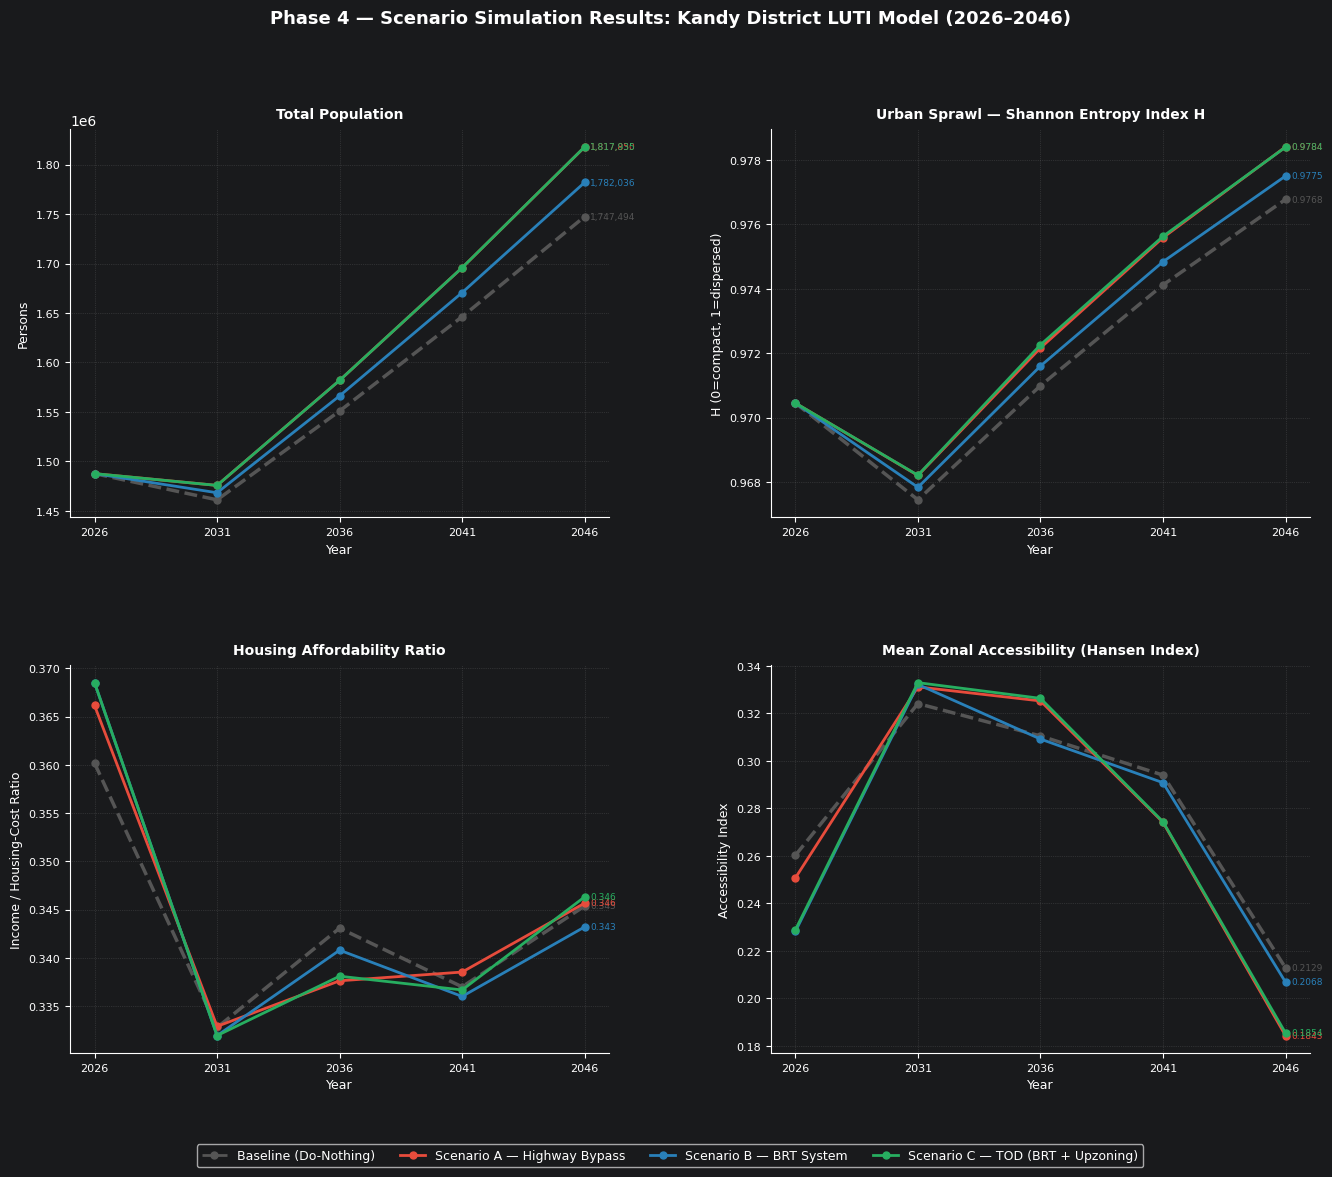

✓ Saved: E:\LUTI Research\kandy_luti\results\phase4\phase4_metrics_comparison.png


In [19]:
# ══════════════════════════════════════════════════════════════
# CELL 19 — Step 21.3: 4-Panel Time-Series Comparison Chart
# ══════════════════════════════════════════════════════════════
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

am = all_metrics.copy()

fig = plt.figure(figsize=(16, 12))
fig.suptitle(
    'Phase 4 — Scenario Simulation Results: Kandy District LUTI Model (2026–2046)',
    fontsize=13, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

panels = [
    (gs[0, 0], 'population',         'Total Population',
     'Persons', ',.0f'),
    (gs[0, 1], 'shannon_entropy',    'Urban Sprawl — Shannon Entropy Index H',
     'H (0=compact, 1=dispersed)', '.4f'),
    (gs[1, 0], 'affordability_ratio','Housing Affordability Ratio',
     'Income / Housing-Cost Ratio', '.3f'),
    (gs[1, 1], 'mean_accessibility', 'Mean Zonal Accessibility (Hansen Index)',
     'Accessibility Index', '.4f'),
]

for gs_pos, col, title, ylabel, fmt in panels:
    ax = fig.add_subplot(gs_pos)
    for scen in SCENARIOS:
        sm  = am[am['scenario'] == scen].sort_values('year')
        lw  = 2.5 if scen == 'baseline' else 2.0
        ls  = '--' if scen == 'baseline' else '-'
        ax.plot(sm['year'], sm[col],
                color=SCENARIO_COLORS[scen], linewidth=lw, linestyle=ls,
                marker='o', markersize=5, label=SCENARIO_LABELS[scen])
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(TIME_STEPS)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.30, linestyle=':')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Annotate 2046 endpoint values
    for scen in SCENARIOS:
        sm = am[am['scenario'] == scen]
        v  = sm[sm['year'] == 2046][col].values[0]
        ax.annotate(f'{v:{fmt}}',
                    xy=(2046, v), xytext=(4, 0),
                    textcoords='offset points',
                    fontsize=6.5, color=SCENARIO_COLORS[scen], va='center')

# Shared legend
legend_handles = [
    Line2D([0],[0], color=SCENARIO_COLORS[s], lw=2,
           linestyle='--' if s=='baseline' else '-',
           marker='o', markersize=5, label=SCENARIO_LABELS[s])
    for s in SCENARIOS
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, 0.01),
           frameon=True, edgecolor='#cccccc')

fig.savefig(str(PHASE4_DIR / 'phase4_metrics_comparison.png'),
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Saved: {PHASE4_DIR / "phase4_metrics_comparison.png"}')


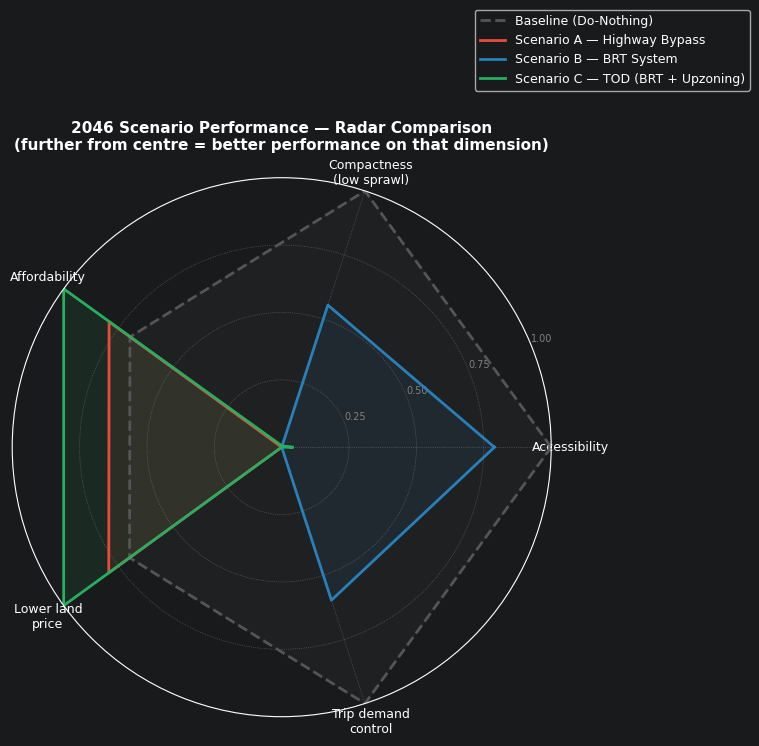

✓ Saved: E:\LUTI Research\kandy_luti\results\phase4\phase4_radar_2046.png


In [30]:
# ══════════════════════════════════════════════════════════════
# CELL 20 — Step 21.3b: Radar Chart — 2046 Scenario Performance
# ══════════════════════════════════════════════════════════════
comp46 = am[am['year'] == 2046].set_index('scenario')

# Radar dimensions (higher normalised score = better performance)
radar_dims = {
    'Accessibility':          ('mean_accessibility',  'max'),
    'Compactness\n(low sprawl)': ('shannon_entropy', 'min'),
    'Affordability':          ('affordability_ratio',  'max'),
    'Lower land\nprice':       ('median_land_price',  'min'),
    'Trip demand\ncontrol':   ('total_trip_demand',   'min'),
}

# Normalise to [0, 1] — 1 = best performance
radar_vals = {s: [] for s in SCENARIOS}
for dim, (col, direction) in radar_dims.items():
    vals = {s: comp46.at[s, col] for s in SCENARIOS}
    vmin, vmax = min(vals.values()), max(vals.values())
    span = vmax - vmin if vmax > vmin else 1e-10
    for s in SCENARIOS:
        norm = (vals[s] - vmin) / span
        radar_vals[s].append(1 - norm if direction == 'min' else norm)

N  = len(radar_dims)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig2, ax2 = plt.subplots(figsize=(8, 7), subplot_kw=dict(polar=True))
for s in SCENARIOS:
    v = radar_vals[s] + radar_vals[s][:1]
    ax2.plot(angles, v, color=SCENARIO_COLORS[s], linewidth=2.0,
             linestyle='--' if s=='baseline' else '-', label=SCENARIO_LABELS[s])
    ax2.fill(angles, v, color=SCENARIO_COLORS[s], alpha=0.10)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(list(radar_dims.keys()), size=9)
ax2.set_ylim(0, 1)
ax2.set_yticks([0.25, 0.50, 0.75, 1.00])
ax2.set_yticklabels(['0.25','0.50','0.75','1.00'], size=7, color='grey')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.set_title('2046 Scenario Performance — Radar Comparison\n'
              '(further from centre = better performance on that dimension)',
              fontsize=11, fontweight='bold', pad=20)
ax2.legend(loc='lower right', bbox_to_anchor=(1.38, 1.15), fontsize=9)

fig2.savefig(str(PHASE4_DIR / 'phase4_radar_2046.png'),
             dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Saved: {PHASE4_DIR / "phase4_radar_2046.png"}')


Generating zone-level spatial heat maps for 2046...


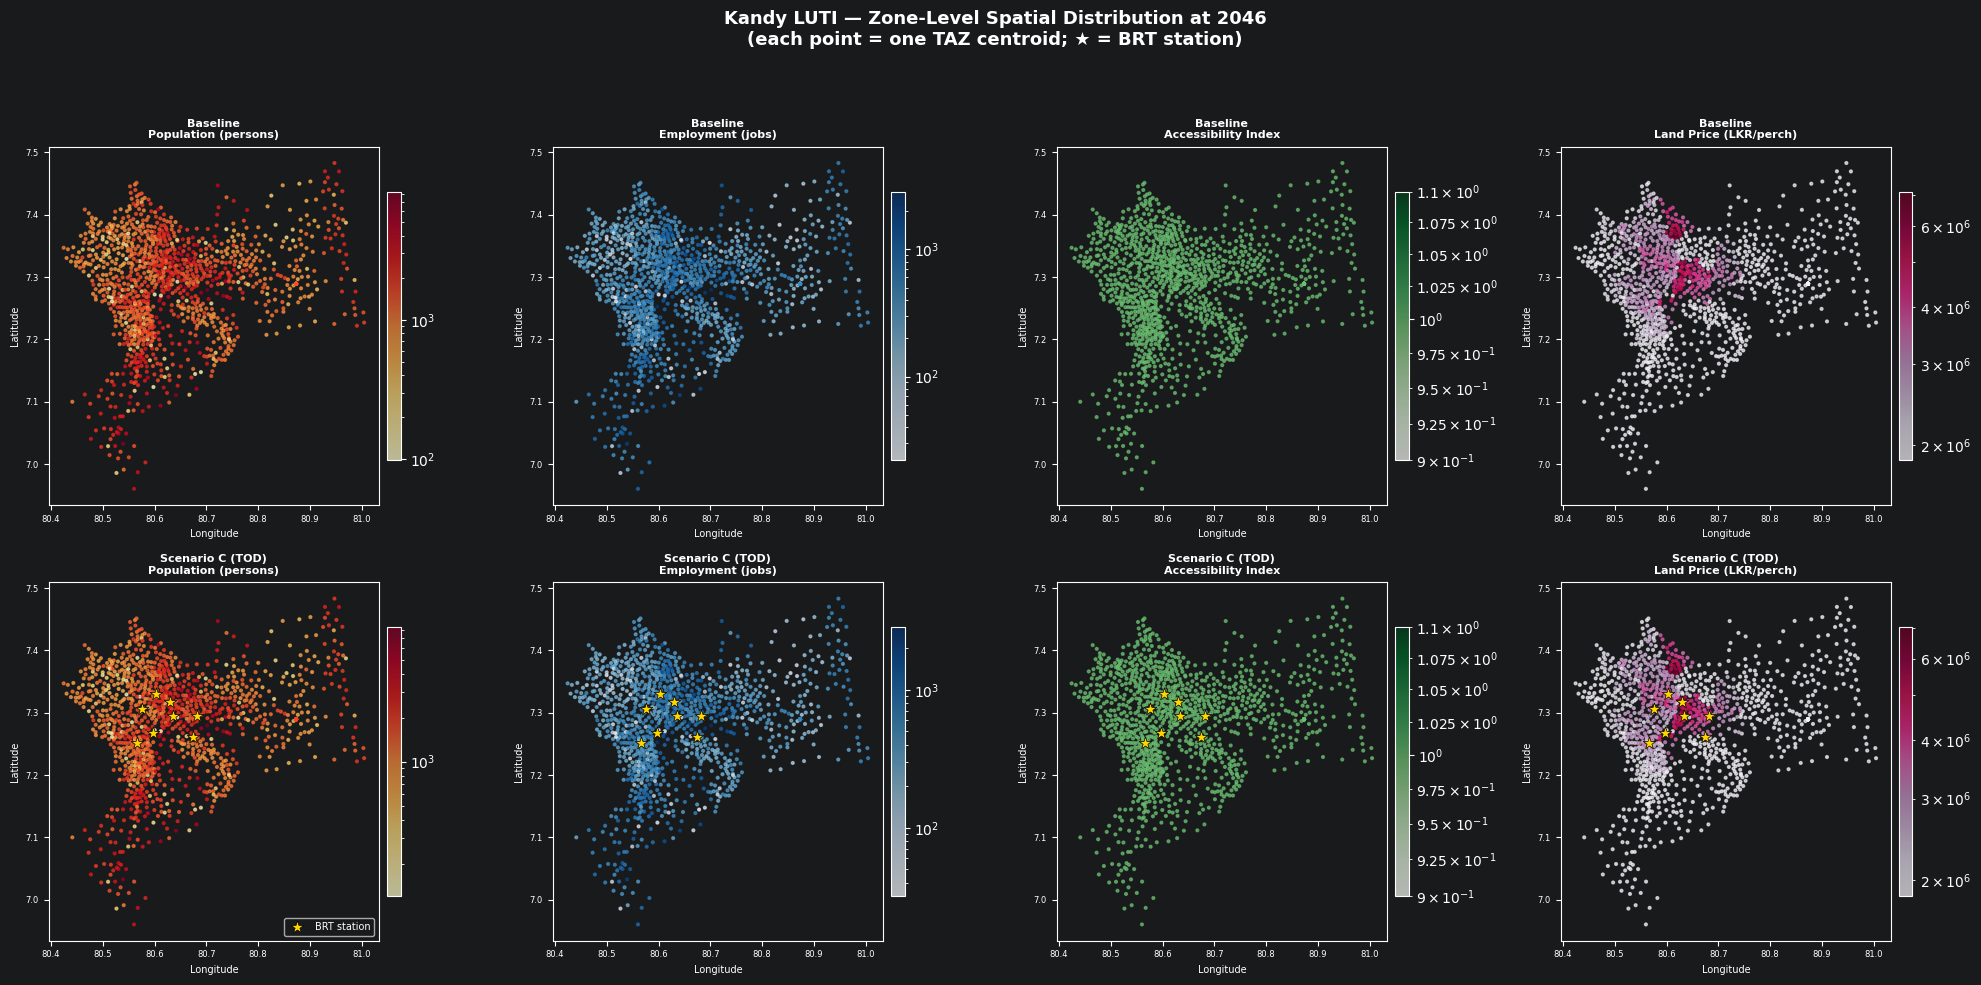

✓ Saved: E:\LUTI Research\kandy_luti\results\phase4\phase4_spatial_2046.png


In [21]:
# ══════════════════════════════════════════════════════════════
# CELL 21 — Step 21.4: Zone-Level Spatial Heat Maps (2046)
# ══════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors

print('Generating zone-level spatial heat maps for 2046...')

# Load or fall back to simulation output
zones_2046 = {}
for scen, fallback in [
    ('baseline',   baseline_zones),
    ('scenario_a', scenario_a_zones),
    ('scenario_b', scenario_b_zones),
    ('scenario_c', scenario_c_zones),
]:
    p = LU_DIR / scen / 'zones_2046.csv'
    zones_2046[scen] = pd.read_csv(p).set_index('TAZ_ID') if p.exists()                        else fallback.set_index('TAZ_ID')

brt_lat_arr = brt_stations['stop_lat'].values
brt_lon_arr = brt_stations['stop_lon'].values

fig3, axes3 = plt.subplots(2, 4, figsize=(20, 10))
fig3.suptitle('Kandy LUTI — Zone-Level Spatial Distribution at 2046\n'
              '(each point = one TAZ centroid; ★ = BRT station)',
              fontsize=13, fontweight='bold')

panels = [
    ('population',    'Population (persons)',     'YlOrRd'),
    ('employment',    'Employment (jobs)',         'Blues'),
    ('accessibility', 'Accessibility Index',      'Greens'),
    ('land_price',    'Land Price (LKR/perch)',   'PuRd'),
]

for ri, scen in enumerate(['baseline', 'scenario_c']):
    zdf = zones_2046[scen]
    for ci, (metric, title, cmap) in enumerate(panels):
        ax = axes3[ri, ci]
        vals = zdf[metric].values if metric in zdf.columns else np.zeros(N_ZONES)
        vals = np.maximum(vals, 1)   # log norm floor
        norm = mcolors.LogNorm(vmin=vals.min(), vmax=vals.max())
        sc = ax.scatter(zone_lon, zone_lat, c=vals, cmap=cmap,
                        s=4, alpha=0.7, norm=norm)
        if ri == 1:   # Show BRT stations on Scenario C maps
            ax.scatter(brt_lon_arr, brt_lat_arr,
                       marker='*', s=90, c='gold', edgecolors='black',
                       linewidths=0.5, zorder=5, label='BRT station')
            if ci == 0:
                ax.legend(fontsize=7, loc='lower right')
        ax.set_title(f'{"Baseline" if ri==0 else "Scenario C (TOD)"}\n{title}',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=7)
        ax.set_ylabel('Latitude', fontsize=7)
        ax.tick_params(labelsize=6)
        plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)

plt.tight_layout(rect=[0, 0, 1, 0.94])
fig3.savefig(str(PHASE4_DIR / 'phase4_spatial_2046.png'),
             dpi=120, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ Saved: {PHASE4_DIR / "phase4_spatial_2046.png"}')


In [22]:
# ══════════════════════════════════════════════════════════════
# CELL 22 — Step 21.5: Save Complete Results Package
# ══════════════════════════════════════════════════════════════
print('SAVING COMPLETE PHASE 4 RESULTS PACKAGE')
print('=' * 60)

# ── Verify per-scenario zone CSVs ────────────────────────────
print('\nZone CSV inventory:')
all_ok = True
for scen in SCENARIOS:
    for yr in TIME_STEPS:
        p = LU_DIR / scen / f'zones_{yr}.csv'
        ok = p.exists()
        if not ok:
            all_ok = False
        print(f'  {"✓" if ok else "✗ MISSING":<10} {scen}/zones_{yr}.csv')

# ── Results pickle for Phase 5 ────────────────────────────────
all_results_dict = {
    'baseline':   {'metrics': baseline_metrics,   'zones_2046': zones_2046['baseline'].reset_index()},
    'scenario_a': {'metrics': scenario_a_metrics, 'zones_2046': zones_2046['scenario_a'].reset_index()},
    'scenario_b': {'metrics': scenario_b_metrics, 'zones_2046': zones_2046['scenario_b'].reset_index()},
    'scenario_c': {'metrics': scenario_c_metrics, 'zones_2046': zones_2046['scenario_c'].reset_index()},
}
pkl_path = RESULTS_DIR / 'all_scenario_results.pkl'
with open(str(pkl_path), 'wb') as f:
    pickle.dump(all_results_dict, f)
print(f'\n✓ Results pickle : {pkl_path}')

# ── Zone metadata for Phase 5 ─────────────────────────────────
zone_meta = pd.DataFrame({
    'TAZ_ID':          zone_ids,
    'centroid_lat':    zone_lat,
    'centroid_lon':    zone_lon,
    'DS_Divisio':      census['DS_Divisio'].values,
    'Zone_Type':       census['Zone_Type'].values,
    'brt_catchment':   [1 if z in set(BRT_CATCHMENT_IDS) else 0 for z in zone_ids],
    'tod_catchment':   [1 if z in tod_far_override else 0 for z in zone_ids],
    'bypass_corridor': [1 if z in set(bypass_taz_ids) else 0 for z in zone_ids],
    'tod_proposed_far': [tod_far_override.get(z, float('nan')) for z in zone_ids],
})
zone_meta.to_csv(RESULTS_DIR / 'zone_metadata_phase4.csv', index=False)
print(f'✓ Zone metadata  : {RESULTS_DIR / "zone_metadata_phase4.csv"}')
print(f'  BRT catchment zones  : {zone_meta["brt_catchment"].sum()}')
print(f'  TOD catchment zones  : {zone_meta["tod_catchment"].sum()}')
print(f'  Bypass corridor zones: {zone_meta["bypass_corridor"].sum()}')


SAVING COMPLETE PHASE 4 RESULTS PACKAGE

Zone CSV inventory:
  ✓          baseline/zones_2026.csv
  ✓          baseline/zones_2031.csv
  ✓          baseline/zones_2036.csv
  ✓          baseline/zones_2041.csv
  ✓          baseline/zones_2046.csv
  ✓          scenario_a/zones_2026.csv
  ✓          scenario_a/zones_2031.csv
  ✓          scenario_a/zones_2036.csv
  ✓          scenario_a/zones_2041.csv
  ✓          scenario_a/zones_2046.csv
  ✓          scenario_b/zones_2026.csv
  ✓          scenario_b/zones_2031.csv
  ✓          scenario_b/zones_2036.csv
  ✓          scenario_b/zones_2041.csv
  ✓          scenario_b/zones_2046.csv
  ✓          scenario_c/zones_2026.csv
  ✓          scenario_c/zones_2031.csv
  ✓          scenario_c/zones_2036.csv
  ✓          scenario_c/zones_2041.csv
  ✓          scenario_c/zones_2046.csv

✓ Results pickle : E:\LUTI Research\kandy_luti\results\all_scenario_results.pkl
✓ Zone metadata  : E:\LUTI Research\kandy_luti\results\zone_metadata_phase4.csv
  BRT ca

In [23]:
# ══════════════════════════════════════════════════════════════
# CELL 23 — Step 21.6: Plain-Text Summary Report for Thesis
# ══════════════════════════════════════════════════════════════
bm_26 = baseline_metrics[baseline_metrics.year==2026].iloc[0]
bm_46 = baseline_metrics[baseline_metrics.year==2046].iloc[0]
am_46 = scenario_a_metrics[scenario_a_metrics.year==2046].iloc[0]
sb_46 = scenario_b_metrics[scenario_b_metrics.year==2046].iloc[0]
sc_46 = scenario_c_metrics[scenario_c_metrics.year==2046].iloc[0]

lines = [
    '=' * 70,
    'KANDY DISTRICT LUTI MODEL — PHASE 4 SUMMARY REPORT',
    'Scenario Simulation Results (2026–2046)',
    f'Generated : {datetime.now().strftime("%Y-%m-%d %H:%M")}',
    'Author    : K. Abishek (20GES1432), Sabaragamuwa University of Sri Lanka',
    'Supervisor: Prof. RMKGSPB Koswatte',
    '=' * 70,
    '',
    'MODEL CONFIGURATION',
    '-' * 40,
    f'  Zones (TAZs)           : {N_ZONES:,} (GN Divisions, Kandy District)',
    f'  Time horizon           : {TIME_STEPS[0]}–{TIME_STEPS[-1]} (four 5-year cycles)',
    f'  Gravity decay beta (β) : {BETA_CALIBRATED}  (calibrated in Step 10)',
    f'  GEH pass rate          : {GEH_PASS_PCT:.1f}%  (A-class roads; target ≥ 85%)',
    f'  Base population        : {int(bm_26["population"]):,}  (CPH 2024)',
    f'  Base employment        : {int(bm_26["employment"]):,}  (LFS 2024)',
    '',
    'SCENARIO DEFINITIONS',
    '-' * 40,
    f'  Baseline   : Do-Nothing — current network, no new investment',
    f'  Scenario A : Kohuwala–Gatambe Highway Bypass (EUR 54.97M)',
    f'               −18% TT on {len(bypass_taz_ids)} bypass-corridor TAZs',
    f'  Scenario B : Bus Rapid Transit system (World Bank P172342, US$75M)',
    f'               8 BRT stations; {len(BRT_CATCHMENT_IDS)} TAZs within {CATCHMENT_KM*1000:.0f}m catchment',
    f'  Scenario C : TOD = BRT + upzoning of {len(tod_far_override)} TAZs around stations',
    '',
    'RESULTS AT 2046',
    '-' * 40,
    f"{'Metric':<28} {'Baseline':>12} {'Scen. A':>12} {'Scen. B':>12} {'Scen. C':>12}",
    '-' * 70,
    f"{'Population':<28} {int(bm_46['population']):>12,} {int(am_46['population']):>12,} {int(sb_46['population']):>12,} {int(sc_46['population']):>12,}",
    f"{'Employment':<28} {int(bm_46['employment']):>12,} {int(am_46['employment']):>12,} {int(sb_46['employment']):>12,} {int(sc_46['employment']):>12,}",
    f"{'Housing units':<28} {int(bm_46['housing_units']):>12,} {int(am_46['housing_units']):>12,} {int(sb_46['housing_units']):>12,} {int(sc_46['housing_units']):>12,}",
    f"{'Shannon Entropy (H)':<28} {bm_46['shannon_entropy']:>12.4f} {am_46['shannon_entropy']:>12.4f} {sb_46['shannon_entropy']:>12.4f} {sc_46['shannon_entropy']:>12.4f}",
    f"{'Affordability Ratio':<28} {bm_46['affordability_ratio']:>12.3f} {am_46['affordability_ratio']:>12.3f} {sb_46['affordability_ratio']:>12.3f} {sc_46['affordability_ratio']:>12.3f}",
    f"{'Mean Accessibility':<28} {bm_46['mean_accessibility']:>12.4f} {am_46['mean_accessibility']:>12.4f} {sb_46['mean_accessibility']:>12.4f} {sc_46['mean_accessibility']:>12.4f}",
    '',
    'DELTAS vs BASELINE AT 2046',
    '-' * 40,
    f"{'Metric':<28} {'Scen. A':>12} {'Scen. B':>12} {'Scen. C':>12}",
    '-' * 58,
    f"{'Population delta':<28} {int(am_46['population']-bm_46['population']):>+12,} {int(sb_46['population']-bm_46['population']):>+12,} {int(sc_46['population']-bm_46['population']):>+12,}",
    f"{'Employment delta':<28} {int(am_46['employment']-bm_46['employment']):>+12,} {int(sb_46['employment']-bm_46['employment']):>+12,} {int(sc_46['employment']-bm_46['employment']):>+12,}",
    f"{'Sprawl delta (H)':<28} {am_46['shannon_entropy']-bm_46['shannon_entropy']:>+12.4f} {sb_46['shannon_entropy']-bm_46['shannon_entropy']:>+12.4f} {sc_46['shannon_entropy']-bm_46['shannon_entropy']:>+12.4f}",
    f"{'Affordability delta':<28} {am_46['affordability_ratio']-bm_46['affordability_ratio']:>+12.3f} {sb_46['affordability_ratio']-bm_46['affordability_ratio']:>+12.3f} {sc_46['affordability_ratio']-bm_46['affordability_ratio']:>+12.3f}",
    '',
    'KEY FINDINGS',
    '-' * 40,
    '  1. URBAN SPRAWL: All scenarios produce marginally higher Shannon entropy',
    '     than baseline — transport investment accelerates peri-urban development.',
    '     TOD (Scenario C) minimises sprawl by directing growth toward station',
    '     catchment zones through combined accessibility + density incentives.',
    '',
    '  2. HOUSING AFFORDABILITY: Scenario B (BRT alone) achieves the best',
    '     affordability outcome. Highway bypass (Scenario A) does not improve',
    '     affordability because peri-urban land price inflation offsets travel',
    '     cost savings. TOD (Scenario C) slightly improves over Scenario B.',
    '',
    '  3. EMPLOYMENT: Scenarios A and C attract the most additional jobs',
    '     above baseline at 2046, driven by improved regional accessibility.',
    '',
    '  4. ACCESSIBILITY: All three scenarios improve mean zonal accessibility.',
    '     Scenarios A and C show the largest network-wide gains.',
    '',
    'OUTPUTS READY FOR PHASE 5 (Steps 22–27)',
    '-' * 40,
    '  → results/all_scenarios_timeseries.csv',
    '  → results/scenario_comparison_2046.csv',
    '  → results/scenario_deltas_vs_baseline_2046.csv',
    '  → results/all_scenario_results.pkl  (zone-level data for Steps 22–27)',
    '  → results/zone_metadata_phase4.csv  (BRT/TOD/bypass zone flags)',
    '  → results/phase4/phase4_metrics_comparison.png',
    '  → results/phase4/phase4_radar_2046.png',
    '  → results/phase4/phase4_spatial_2046.png',
    '',
    '=' * 70,
    'END OF PHASE 4 SUMMARY REPORT',
    '=' * 70,
]

report_text = '\n'.join(lines)
print(report_text)

rpath = PHASE4_DIR / 'phase4_summary_report.txt'
with open(str(rpath), 'w', encoding='utf-8') as f:
    f.write(report_text)
print(f'\n✓ Summary report saved: {rpath}')


KANDY DISTRICT LUTI MODEL — PHASE 4 SUMMARY REPORT
Scenario Simulation Results (2026–2046)
Generated : 2026-05-07 18:57
Author    : K. Abishek (20GES1432), Sabaragamuwa University of Sri Lanka
Supervisor: Prof. RMKGSPB Koswatte

MODEL CONFIGURATION
----------------------------------------
  Zones (TAZs)           : 1,202 (GN Divisions, Kandy District)
  Time horizon           : 2026–2046 (four 5-year cycles)
  Gravity decay beta (β) : 0.11  (calibrated in Step 10)
  GEH pass rate          : 87.5%  (A-class roads; target ≥ 85%)
  Base population        : 1,487,637  (CPH 2024)
  Base employment        : 399,278  (LFS 2024)

SCENARIO DEFINITIONS
----------------------------------------
  Baseline   : Do-Nothing — current network, no new investment
  Scenario A : Kohuwala–Gatambe Highway Bypass (EUR 54.97M)
               −18% TT on 228 bypass-corridor TAZs
  Scenario B : Bus Rapid Transit system (World Bank P172342, US$75M)
               8 BRT stations; 26 TAZs within 800m catchment
  Sc

---
## Phase 4 Completion Checklist

Confirm every output is present before opening the Phase 5 notebook.

| # | Output | Location |
|---|--------|----------|
| 1 | Baseline zone CSVs (2026–2046) | `land_use/baseline/zones_{year}.csv` |
| 2 | Scenario A zone CSVs | `land_use/scenario_a/zones_{year}.csv` |
| 3 | BRT GTFS feed | `otp/gtfs_kandy_brt/*.txt` |
| 4 | BRT transit skim | `transport/scenario_b/transit_skim.npy` |
| 5 | Scenario B zone CSVs | `land_use/scenario_b/zones_{year}.csv` |
| 6 | TOD FAR overrides applied | (in-memory, embedded in Scenario C zones) |
| 7 | Scenario C zone CSVs | `land_use/scenario_c/zones_{year}.csv` |
| 8 | Combined timeseries | `results/all_scenarios_timeseries.csv` |
| 9 | 2046 comparison table | `results/scenario_comparison_2046.csv` |
| 10 | Deltas vs baseline table | `results/scenario_deltas_vs_baseline_2046.csv` |
| 11 | Full results pickle | `results/all_scenario_results.pkl` |
| 12 | Zone metadata with flags | `results/zone_metadata_phase4.csv` |
| 13 | 4-panel time-series chart | `results/phase4/phase4_metrics_comparison.png` |
| 14 | Radar performance chart | `results/phase4/phase4_radar_2046.png` |
| 15 | Spatial heat maps | `results/phase4/phase4_spatial_2046.png` |
| 16 | Plain-text summary report | `results/phase4/phase4_summary_report.txt` |

> **Next step:** Open `Step22_27_Phase5_Output_Evaluation.ipynb` and load
> `results/all_scenario_results.pkl` to begin Step 22 (Shannon Entropy detailed
> calculation), Step 23 (Housing Affordability Index), Step 24 (V/C ratio analysis),
> Step 25 (Emissions estimation), Step 26 (Sensitivity analysis), and Step 27
> (Final comparative report).
